<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

In [ ]:
import pandas as pd

df = pd.read_excel("data_problems_translated.xlsx", index_col=0)

print(df.shape)
df.head()

(5273, 2)


,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms
3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,"Dima, who came from Vrunlandia, said that ther...",graphs


In [ ]:
# Изучим датасет

print(f'Уникальных топиков: {df.topic.nunique()}')
df.topic.value_counts()

Уникальных топиков: 7


,count
topic,
number_theory,2396
combinatorics,1020
dirichlet,441
polynoms,426
graphs,384
geometry,371
invariant,235


,problem_text_length
count,5273.000000
mean,229.931538
std,215.601297
min,0.000000
25%,105.000000
50%,179.000000
75%,286.000000
max,2506.000000


<Axes: >

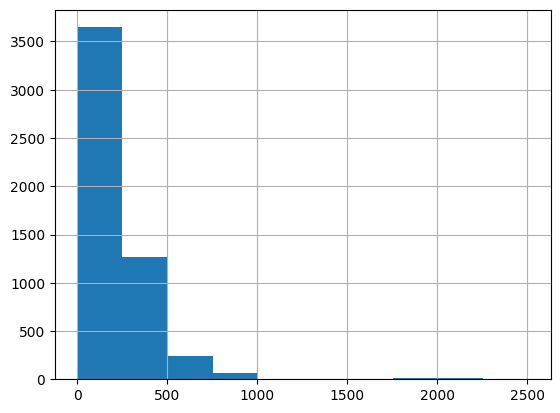

In [ ]:
# Приводим к строкам
df['problem_text'] = df['problem_text'].fillna('').astype(str)

# Колонка с длинной текстовки "problem_text"
df['problem_text_length'] = df.problem_text.apply(lambda x: len(str(x)))

display(df.describe())
df.problem_text_length.hist()

In [ ]:
# Интересно, есть вот Проблемы без текста, а есть очень длинные.  Разберемся с ними позже.
# В целом, нужно немного "почистить" датасет.

# Дубликаты строк(по всему набору полей)
duplicates = df[df.duplicated()]
display(duplicates)

,problem_text,topic,problem_text_length
116,(c),combinatorics,3
834,(b)..............................................,polynoms,68
1287,(a)..............................................,polynoms,68
1636,(g),polynoms,3
2273,(b)..............................................,combinatorics,68
2367,(a)..............................................,polynoms,68
2496,Find all valid system solutions,polynoms,31
2497,"It's okay. It's okay, it's okay, it's okay.",graphs,43
2760,"It's okay. It's okay, it's okay, it's okay.",combinatorics,43
3218,Prove that if you put any number of threes in ...,number_theory,101


In [ ]:
# Дубли Пролем - т.е. по колонке "problem_text"
problem_text_dups = df[df.duplicated('problem_text', keep=False)]
display(problem_text_dups)

,problem_text,topic,problem_text_length
2,The quadratic three-member graph with the coef...,polynoms,203
3,Can you draw on the surface of Rubik's cube a ...,combinatorics,149
4,"Dima, who came from Vrunlandia, said that ther...",graphs,201
6,Can n sit 2n + 1 round table so that no two si...,graphs,144
11,The circulatory legs are located in the knots ...,number_theory,335
...,...,...,...
5259,How many different ways are there to divide th...,number_theory,317
5262,The tournament is run by 2m teams. In the firs...,graphs,215
5263,Can seven phones be wired so that each phone i...,combinatorics,75
5265,"In the country of 2,000 cities, every city is ...",graphs,382


In [ ]:
df[df.problem_text.str.contains("Can you draw on the surface of Rubik's cube a")]

,problem_text,topic,problem_text_length
3,Can you draw on the surface of Rubik's cube a ...,combinatorics,149
5224,Can you draw on the surface of Rubik's cube a ...,graphs,149


In [ ]:
# Проблемы классифицированы по разным топикам. В принципе это допустимо.

In [ ]:
# Посмотрим Проблемы, в тексте которых много точек
df[df.problem_text.str.contains(".........", regex=False)]


,problem_text,topic,problem_text_length
93,(b)..............................................,combinatorics,68
410,Comment Decision Objective 73697 Themes: [The ...,dirichlet,330
584,On the sides of the bulge quadrilateral as on ...,dirichlet,698
748,(b)..............................................,polynoms,68
834,(b)..............................................,polynoms,68
891,The yellow triangle is bounded with red if the...,combinatorics,668
899,(a)..............................................,polynoms,68
1025,Two natural numbers of m and n are given. All ...,number_theory,280
1287,(a)..............................................,polynoms,68
1716,(e)..............................................,combinatorics,68


In [ ]:
# После первичного изучения датасета видно:
# 1) В датасете много дублей.
# 2) Многие Проблемы относятся сразу к нескольким топикам.
# 3) Формулировки многих Проблем нельзя назвать адекватными, т.к. они содержат много точек и букву, но при этом относятся к разным топикам.
#
# П.1 и п.2 мне кажутся допустимыми, т.к. то, что Проблема относится к нескольким топикам - вполне разумно(как н-р понятие вероятности м.б. отнесено к терверу и к статистике и т.п.).
# А вот проблемы вроде "(a).............................................." и т.п. кажутся неадекватными.

In [ ]:
# Пробуем заменить длинные точечные последовательности (более 12 символов точек) на пустую подстроку.
df['problem_text'] = df['problem_text'].str.replace(r'\.{12,}', '', regex=True)
df['problem_text'] = df['problem_text'].str.strip()

In [ ]:
# Пересчитаем длины строк
df['problem_text_length'] = df.problem_text.apply(lambda x: len(str(x)))

In [ ]:
# Удалим все строки, где длинна "problem_text" < 4 символов. Сюда попадут строки с ошибками и вида "(b)" и т.п.
df = df[df['problem_text'].str.len() >= 4]

In [ ]:
# Дубли по колонке "problem_text", но с сортировкой по возрастанию по длине "problem_text_length"
problem_text_dups = df[df.duplicated('problem_text', keep=False)] \
    .sort_values(by='problem_text_length', ascending=True)

display(problem_text_dups)

,problem_text,topic,problem_text_length
4485,Prove that,number_theory,10
4407,Prove that,combinatorics,10
4073,Prove that,combinatorics,10
1658,Prove that,number_theory,10
3836,(c) at n > 6.,combinatorics,13
...,...,...,...
4981,"In the kingdom of N cities, some of whose pair...",graphs,849
5186,"In the kingdom of N cities, some of whose pair...",combinatorics,849
1436,The reinforcement system consists of pancakes....,number_theory,870
2186,The reinforcement system consists of pancakes....,graphs,870


,problem_text_length
count,5240.000000
mean,230.957252
std,215.503446
min,10.000000
25%,106.000000
50%,180.000000
75%,287.000000
max,2506.000000


<Axes: >

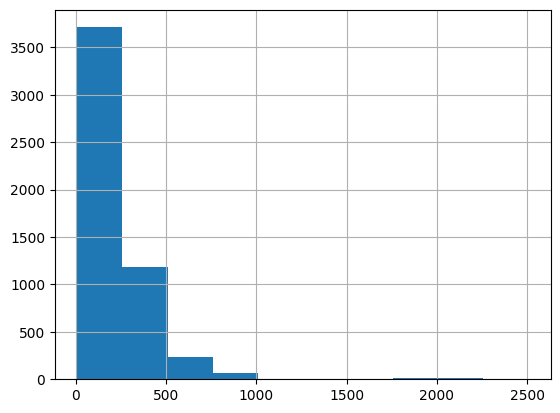

In [ ]:
display(df.describe())
df.problem_text_length.hist()

In [ ]:
# Из статистики длин Проблем видно, что в датасете есть строки, где текст(Проблем) сильно выше среднего(mean=231, std=215), большинство текстов короче 300 символов.
# Решение: в последствии ограничимся длинной Проблем в 512 символов. Специально удалять длинные строки не будем.

In [ ]:
print(df.shape)

(5240, 3)


### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [ ]:
import transformers

In [ ]:
pip install --upgrade transformers

In [ ]:
# ### This is just an interface example. You may change it if you want.
#
# class TransformerClassificationModel(nn.Module):
#     def __init__(base_transformer_model: Union[str, nn.Module]):
#         self.backbone = #...
#         # YOUR CODE: create additional layers for classfication
#
#     def forward(inputs, ...):
#         # YOUR CODE: propagate inputs through the model. Return dict with logits
#
#         outputs = {<YOUR CODE>}
#         return # YOUR CODE
# # # # # # # # # # # # # # #

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model, dropout, num_classes):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(base_transformer_model)
        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask, labels=None):
        # Пропускаем через backbone
        transformer_out = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Берём выход [CLS] токена
        if hasattr(transformer_out, "pooler_output") and transformer_out.pooler_output is not None:
            outputs = transformer_out.pooler_output
        else:
            outputs = transformer_out.last_hidden_state[:, 0, :]  # [CLS] токен

        logits = self.classifier(self.dropout(outputs))

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)


        return {"loss": loss, "logits": logits}

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [ ]:
# def freeze_backbone_function(model: TransformerClassificationModel):
#     pass
# # # # # # # # #

In [ ]:
def freeze_backbone_function(model: TransformerClassificationModel):

    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [ ]:
# import copy
#
# def train_transformer(transformer_model, freeze_backbone=True)
#     model = copy.copy(transformer_model)
#     ### YOUR CODE IS HERE
#
#     return finetuned_model
# # # # # # # # # # # # # # #

In [ ]:
import copy
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import set_seed

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted'),
        'precision': precision_score(labels, preds, average='weighted'),
        'recall': recall_score(labels, preds, average='weighted')
    }

def train_transformer(transformer_model, train_dataset, val_dataset, freeze_backbone):
    set_seed(42)
    model = copy.deepcopy(transformer_model)

    if freeze_backbone:
        freeze_backbone_function(model)

    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        weight_decay=0.01,
        eval_strategy="steps",
        eval_steps=150,
        logging_steps=150,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"\nEvaluation metrics: {metrics}\n")

    logs_df = pd.DataFrame(trainer.state.log_history)
    return trainer, logs_df

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [ ]:
# rubert_tiny_transformer_model = #...
# rubert_tiny_finetuned_with_freezed_backbone = train_transformer(rubert_tiny_transformer_model, freeze_backbone=True)
#
# rubert_tiny_transformer_model = #...
# rubert_tiny_full_finetuned = train_transformer(rubert_tiny_transformer_model, freeze_backbone=False)
# # # # # # # # # # # #

# См.чуть ниже

In [ ]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2)

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

'cuda'

In [ ]:
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModel

# Кастомный Dataset
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, label_to_id, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.label_to_id = label_to_id
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label_str = self.labels[idx]
        label = self.label_to_id[label_str]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def prepare_data(df, train_df, val_df, model_name, feat_name, target, max_length=512):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    unique_labels = sorted(df[target].unique())
    label_to_id = {label: i for i, label in enumerate(unique_labels)}
    id_to_label = {i: label for label, i in label_to_id.items()}

    train_dataset = TextClassificationDataset(
        train_df[feat_name].tolist(),
        train_df[target].tolist(),
        tokenizer,
        label_to_id,
        max_length
    )

    val_dataset = TextClassificationDataset(
        val_df[feat_name].tolist(),
        val_df[target].tolist(),
        tokenizer,
        label_to_id,
        max_length
    )

    return train_dataset, val_dataset, label_to_id, id_to_label, tokenizer

In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(logs1, logs2, label1="Frozen Backbone", label2="Full Fine-Tune"):
    plt.figure(figsize=(16,12))

    # 1. Loss
    plt.subplot(2,2,1)
    plt.plot(logs1['step'], logs1.get('loss').fillna(method='ffill'), label=f'Train Loss {label1}', color='blue')
    plt.plot(logs1['step'], logs1.get('eval_loss').fillna(method='ffill'), label=f'Val Loss {label1}', color='orange')
    plt.plot(logs2['step'], logs2.get('loss').fillna(method='ffill'), label=f'Train Loss {label2}', color='green')
    plt.plot(logs2['step'], logs2.get('eval_loss').fillna(method='ffill'), label=f'Val Loss {label2}', color='red')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()

    # 2. Accuracy
    plt.subplot(2,2,2)
    plt.plot(logs1['step'], logs1.get('eval_accuracy').fillna(method='ffill'), label=f'Accuracy {label1}', color='blue')
    plt.plot(logs2['step'], logs2.get('eval_accuracy').fillna(method='ffill'), label=f'Accuracy {label2}', color='green')
    plt.xlabel('Step')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.legend()

    # 3. F1
    plt.subplot(2,2,3)
    plt.plot(logs1['step'], logs1.get('eval_f1').fillna(method='ffill'), label=f'F1 {label1}', color='blue')
    plt.plot(logs2['step'], logs2.get('eval_f1').fillna(method='ffill'), label=f'F1 {label2}', color='green')
    plt.xlabel('Step')
    plt.ylabel('F1 Score')
    plt.title('Validation F1')
    plt.legend()

    # 4. Precision & Recall
    plt.subplot(2,2,4)
    plt.plot(logs1['step'], logs1.get('eval_precision').fillna(method='ffill'), label=f'Precision {label1}', color='blue', linestyle='dashed')
    plt.plot(logs1['step'], logs1.get('eval_recall').fillna(method='ffill'), label=f'Recall {label1}', color='blue', linestyle='solid')
    plt.plot(logs2['step'], logs2.get('eval_precision').fillna(method='ffill'), label=f'Precision {label2}', color='green', linestyle='dashed')
    plt.plot(logs2['step'], logs2.get('eval_recall').fillna(method='ffill'), label=f'Recall {label2}', color='green', linestyle='solid')
    plt.xlabel('Step')
    plt.ylabel('Score')
    plt.title('Precision & Recall')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
model_name = "cointegrated/rubert-tiny2"
train_dataset, val_dataset, label_to_id, id_to_label, tokenizer = prepare_data(
    df, train_df, val_df, model_name, "problem_text", "topic"
)
num_classes = len(label_to_id)


import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
150,1.920300,1.909107,0.325382,0.280070,0.277145,0.325382
300,1.896900,1.894821,0.372137,0.277106,0.272285,0.372137
450,1.887400,1.888039,0.385496,0.275200,0.301819,0.385496



Evaluation metrics: {'eval_loss': 1.887183666229248, 'eval_accuracy': 0.3883587786259542, 'eval_f1': 0.27517828394765936, 'eval_precision': 0.300483379686501, 'eval_recall': 0.3883587786259542, 'eval_runtime': 3.931, 'eval_samples_per_second': 266.601, 'eval_steps_per_second': 16.79, 'epoch': 2.0}



Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
150,1.598900,1.458899,0.492366,0.358823,0.350117,0.492366
300,1.346900,1.309369,0.520992,0.418982,0.437875,0.520992
450,1.257800,1.262630,0.542939,0.453747,0.445153,0.542939


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipython-input-308479908.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(logs1['step'], logs1.get('loss').fillna(method='ffill'), label=f'Train Loss {label1}', color='blue')
/tmp/ipython-input-308479908.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(logs1['step'], logs1.get('eval_loss').fillna(method='ffill'), label=f'Val Loss {label1}', color='orange')
/tmp/ipython-input-308479908.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a futur


Evaluation metrics: {'eval_loss': 1.2567524909973145, 'eval_accuracy': 0.5381679389312977, 'eval_f1': 0.4512087520536416, 'eval_precision': 0.43996595990894505, 'eval_recall': 0.5381679389312977, 'eval_runtime': 2.469, 'eval_samples_per_second': 424.469, 'eval_steps_per_second': 26.732, 'epoch': 2.0}



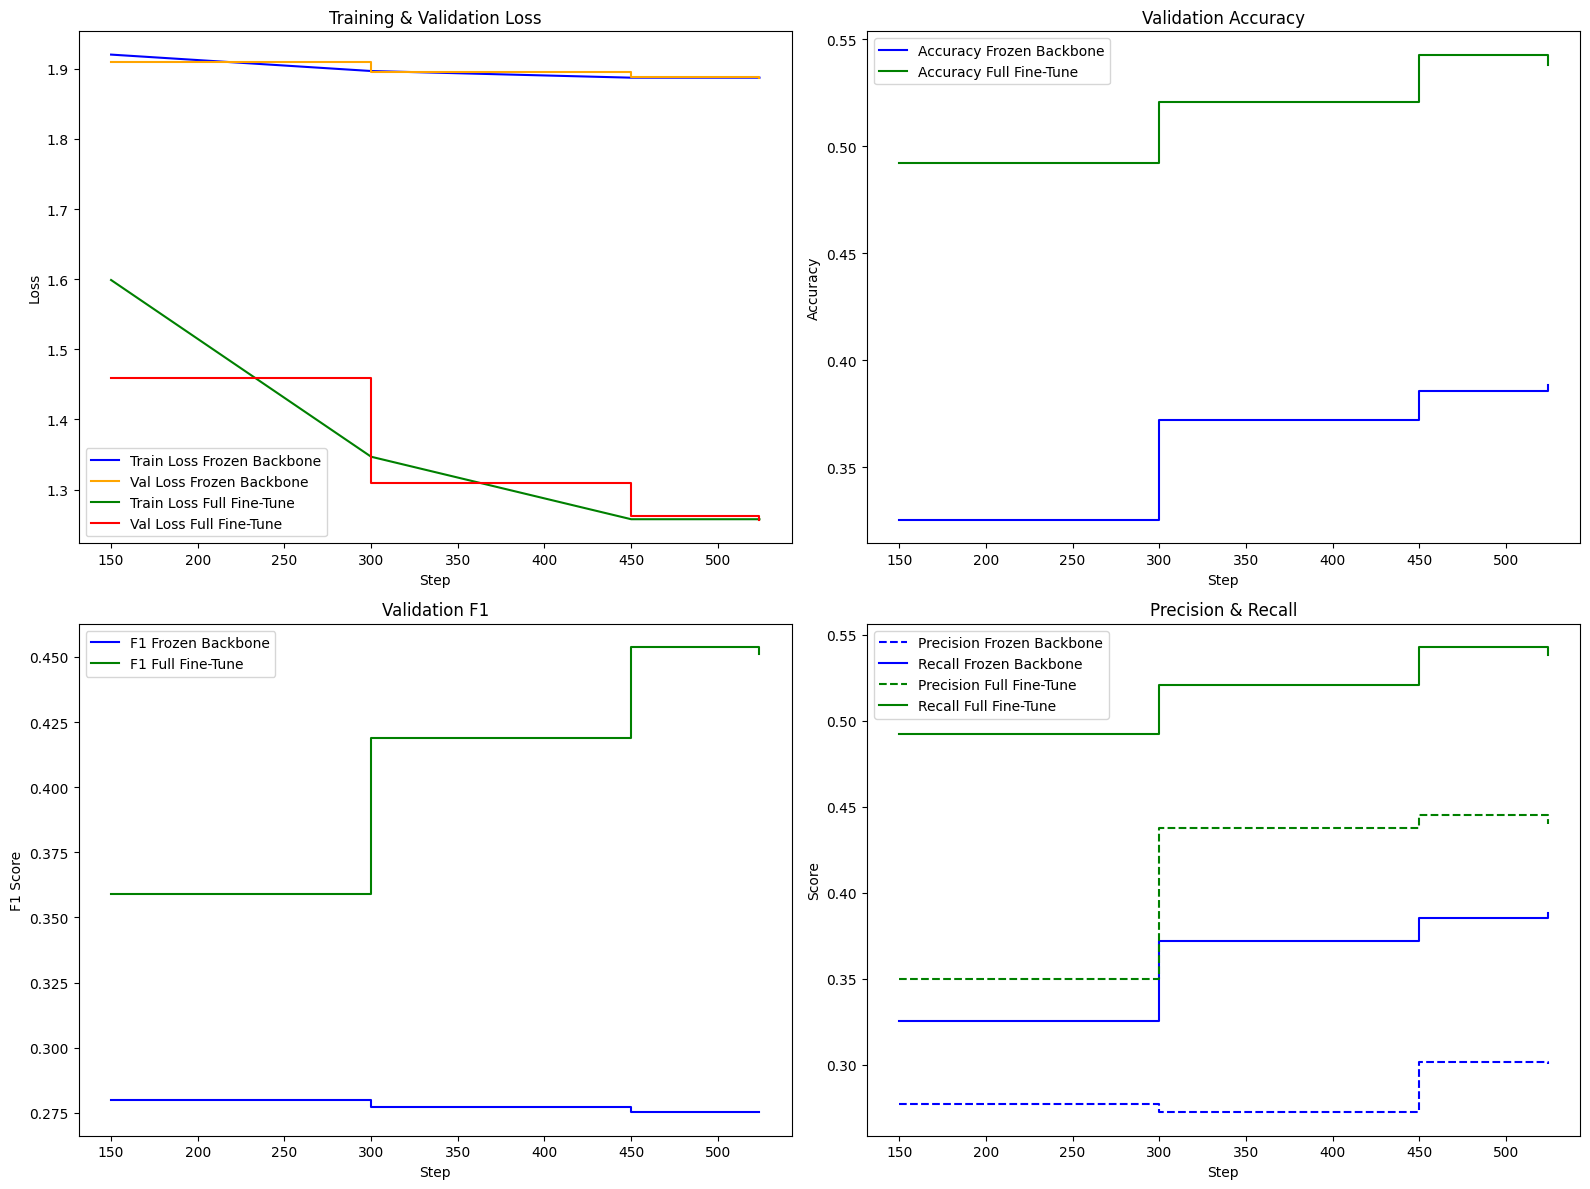

In [ ]:
# 1
rubert_tiny_transformer_model_1 = TransformerClassificationModel(model_name, dropout=0.2, num_classes=num_classes)
trainer_freeze, logs_freeze = train_transformer(
    rubert_tiny_transformer_model_1, train_dataset, val_dataset, freeze_backbone=True
)

# 2
rubert_tiny_transformer_model_2 = TransformerClassificationModel(model_name, dropout=0.2, num_classes=num_classes)
trainer_full, logs_full = train_transformer(
    rubert_tiny_transformer_model_2, train_dataset, val_dataset, freeze_backbone=False
)

plot_metrics(logs_freeze, logs_full)

In [ ]:
# Training & Validation Loss
#
# Замороженный бэкбон: обучение почти не падает, валидационная ошибка почти не меняется, т.е.модель учится медленно, сильно ограничена, потому что backbone не адаптируется.
# Полный fine-tune: тренировка и валидация падают быстрее, т.е. модель лучше подстраивается под данные.
# Вывод: Полное дообучение даёт значительное снижение потерь и, как правило, лучшее качество.
#
#
# Validation Accuracy
#
# Accuracy с замороженным backbone: ~0.39
# Accuracy с full fine-tune: ~0.54
# Вывод: Полное дообучение повышает точность почти на 15%, что подтверждает, что модель учится лучше, когда backbone тоже обновляется.
#
#
# Validation F1
#
# F1 score замороженной модели ~0.275
# F1 score full fine-tune ~0.45
# Вывод: Полное дообучение улучшает баланс precision и recall, модель лучше разделяет классы.
#
#
# Precision & Recall
#
# Замороженный backbone: низкая precision (~0.3) и recall (~0.39)
# Full fine-tune: precision ~0.44, recall ~0.54
# Вывод: Полное дообучение даёт значительно более высокие метрики, особенно recall, модель чаще правильно предсказывает все классы.
#
#
# ВЫВОД: Замороженный backbone ограничивает обучение, модель может только адаптировать классификатор, поэтому метрики остаются низкими. Полный fine-tune значительно улучшает loss, accuracy, F1, precision и recall.

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [ ]:
### YOUR CODE IS HERE (probably, similar on the previous step)

In [ ]:
model_name = "tbs17/MathBert"
train_dataset, val_dataset, label_to_id, id_to_label, tokenizer = prepare_data(
    df, train_df, val_df, model_name, "problem_text", "topic"
)
num_classes = len(label_to_id)


# import os
# os.environ["WANDB_DISABLED"] = "true"
# os.environ["WANDB_MODE"] = "disabled"

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
150,1.910300,1.756506,0.416031,0.268627,0.235581,0.416031
300,1.679700,1.666091,0.435115,0.263846,0.189325,0.435115
450,1.639700,1.650008,0.435115,0.263846,0.189325,0.435115


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluation metrics: {'eval_loss': 1.6486130952835083, 'eval_accuracy': 0.4351145038167939, 'eval_f1': 0.26384602891018355, 'eval_precision': 0.18932463143173475, 'eval_recall': 0.4351145038167939, 'eval_runtime': 32.5802, 'eval_samples_per_second': 32.167, 'eval_steps_per_second': 2.026, 'epoch': 2.0}



Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
150,1.250600,1.052515,0.603053,0.547708,0.546288,0.603053
300,1.012900,1.028331,0.610687,0.541705,0.539607,0.610687
450,0.865200,0.986999,0.606870,0.560454,0.549852,0.606870


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluation metrics: {'eval_loss': 0.9857527017593384, 'eval_accuracy': 0.6154580152671756, 'eval_f1': 0.5768209671843495, 'eval_precision': 0.567901210058563, 'eval_recall': 0.6154580152671756, 'eval_runtime': 32.0811, 'eval_samples_per_second': 32.667, 'eval_steps_per_second': 2.057, 'epoch': 2.0}



/tmp/ipython-input-308479908.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(logs1['step'], logs1.get('loss').fillna(method='ffill'), label=f'Train Loss {label1}', color='blue')
/tmp/ipython-input-308479908.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(logs1['step'], logs1.get('eval_loss').fillna(method='ffill'), label=f'Val Loss {label1}', color='orange')
/tmp/ipython-input-308479908.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(logs2['step'], logs2.get('loss').fillna(method='ffill'), label=f'Train Loss {label2}', color='green')
/tmp/ipython-input-308479908.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.b

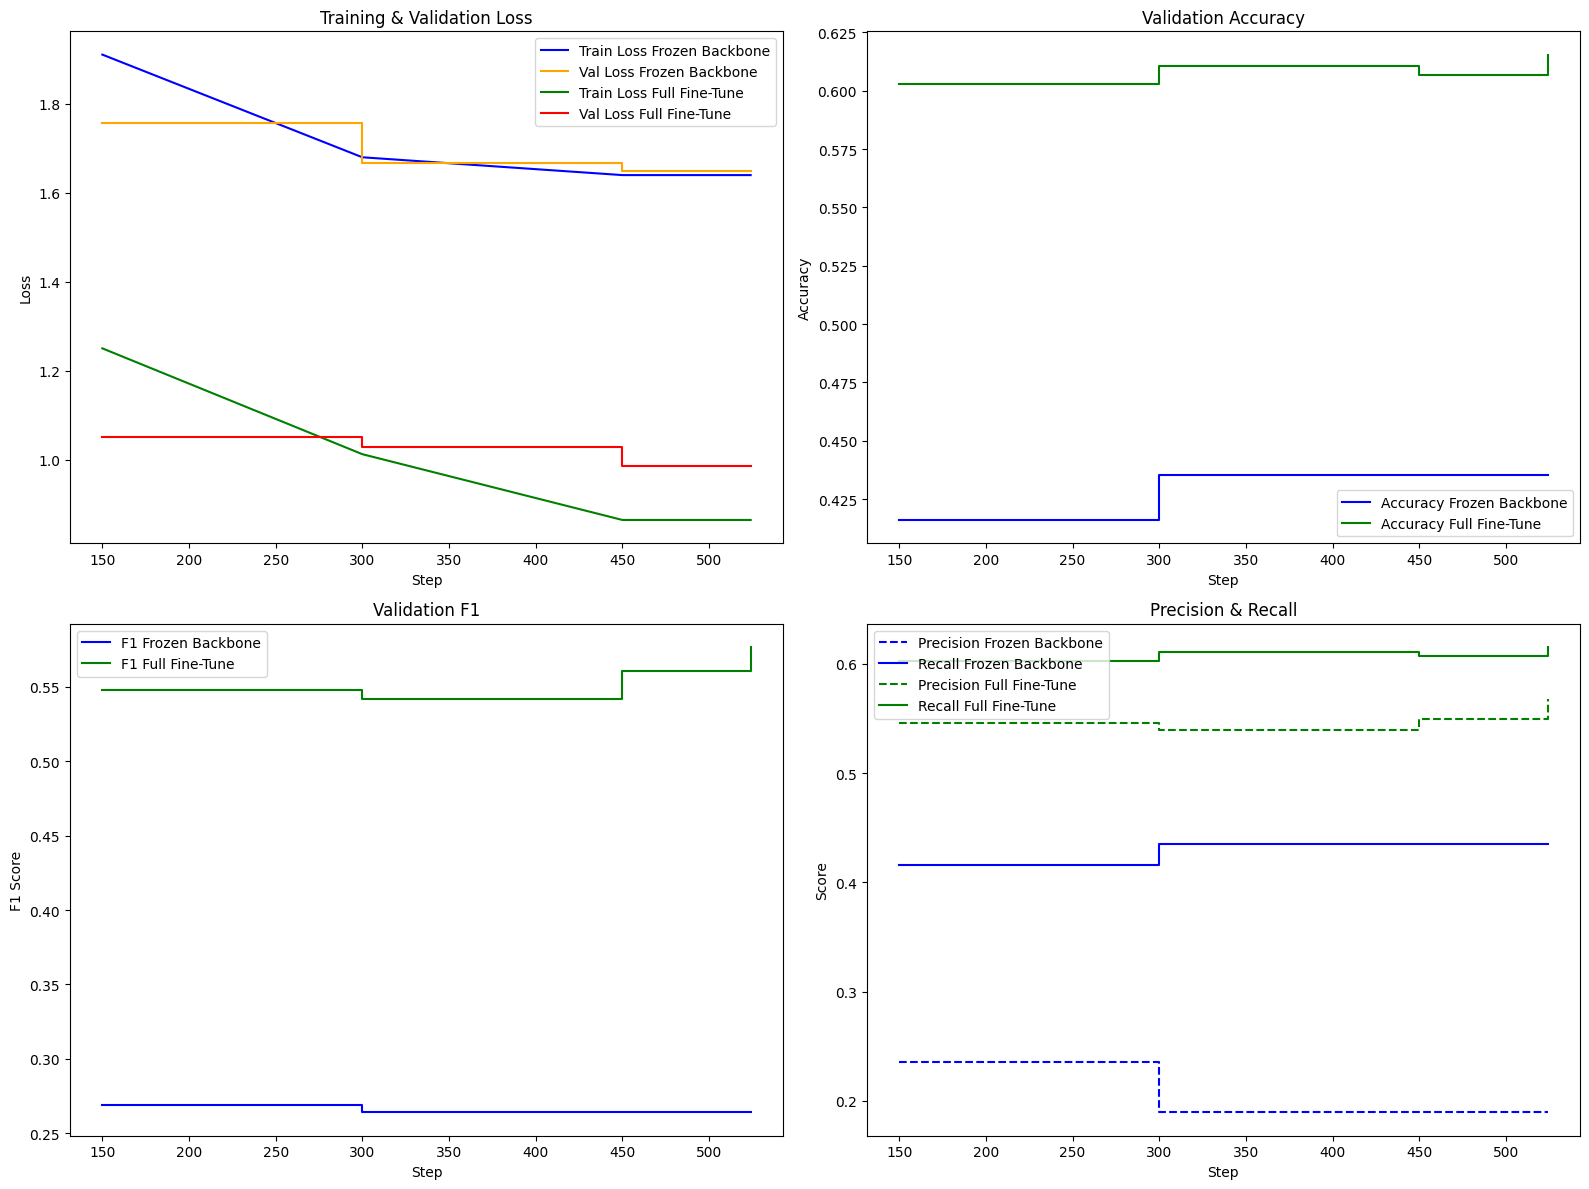

In [ ]:
# 1
MathBert_transformer_model_1 = TransformerClassificationModel(model_name, dropout=0.2, num_classes=num_classes)
# MathBert_finetuned_with_freezed_backbone = train_transformer(MathBert_transformer_model_1, train_dataset, val_dataset,
#                                                                 freeze_backbone=True)
trainer_freeze, logs_freeze = train_transformer(MathBert_transformer_model_1, train_dataset, val_dataset, freeze_backbone=True)


# 2
MathBert_transformer_model_2 = TransformerClassificationModel(model_name, dropout=0.2, num_classes=num_classes)
# MathBert_full_finetuned = train_transformer(MathBert_transformer_model_2, train_dataset, val_dataset,
#                                                                 freeze_backbone=False)
trainer_full, logs_full = train_transformer(MathBert_transformer_model_2, train_dataset, val_dataset, freeze_backbone=False)

# trainer_freeze, logs_freeze = train_transformer(MathBert_transformer_model_1, train_dataset, val_dataset, freeze_backbone=True)
# trainer_full, logs_full = train_transformer(MathBert_transformer_model_2, train_dataset, val_dataset, freeze_backbone=False)

plot_metrics(logs_freeze, logs_full)

In [ ]:
# Вывод по результатам обучения схож с предыдущим экспериментом, цифры немного отличаются, но не значительно. Общие выводы такие же.

# Training & Validation Loss
#
# Замороженный бэкбон: обучение почти не падает, валидационная ошибка почти не меняется, т.е.модель учится медленно, сильно ограничена, потому что backbone не адаптируется.
# Полный fine-tune: тренировка и валидация падают быстрее, т.е. модель лучше подстраивается под данные.
# Вывод: Полное дообучение даёт значительное снижение потерь и, как правило, лучшее качество.
#
#
# Validation Accuracy
#
# Accuracy с замороженным backbone: ~0.43
# Accuracy с full fine-tune: ~0.63
# Вывод: Полное дообучение повышает точность почти на 20%, что подтверждает, что модель учится лучше, когда backbone тоже обновляется.
#
#
# Validation F1
#
# F1 score замороженной модели ~0.19
# F1 score full fine-tune ~0.56
# Вывод: Полное дообучение улучшает баланс precision и recall, модель лучше разделяет классы.
#
#
# Precision & Recall
#
# Замороженный backbone: низкая precision (~0.25) и recall (~0.42)
# Full fine-tune: precision ~0.55, recall ~0.6
# Вывод: Полное дообучение даёт значительно более высокие метрики, особенно recall, модель чаще правильно предсказывает все классы.
#
#
# ВЫВОД: Замороженный backbone ограничивает обучение, модель может только адаптировать классификатор, поэтому метрики остаются низкими. Полный fine-tune значительно улучшает loss, accuracy, F1, precision и recall.

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
# def draw_first_layer_attention_maps(attention_head_ids: List, text: str, model: TransformerClassificationModel):
#     pass

In [ ]:
from typing import List
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

def draw_first_layer_attention_maps(attention_head_ids: List[int], text: str, model: TransformerClassificationModel, tokenizer_name: str):
    import torch
    import matplotlib.pyplot as plt
    import seaborn as sns
    from transformers import AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model.backbone.eval()

    encoding = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]

    with torch.no_grad():
        outputs = model.backbone(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        first_layer_attention = outputs.attentions[0][0]  # первый слой, первый батч

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    seq_len = attention_mask.sum().item()  # реальная длина
    tokens = tokens[:seq_len]

    for head_id in attention_head_ids:
        if head_id >= first_layer_attention.shape[0]:
            print(f"Head {head_id} не существует.")
            continue

        attn_matrix = first_layer_attention[head_id][:seq_len, :seq_len].cpu().numpy()

        plt.figure(figsize=(10, 8))
        sns.heatmap(attn_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
        plt.title(f"Attention Map - Layer 0, Head {head_id}")
        plt.xlabel("Key Tokens")
        plt.ylabel("Query Tokens")
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.show()

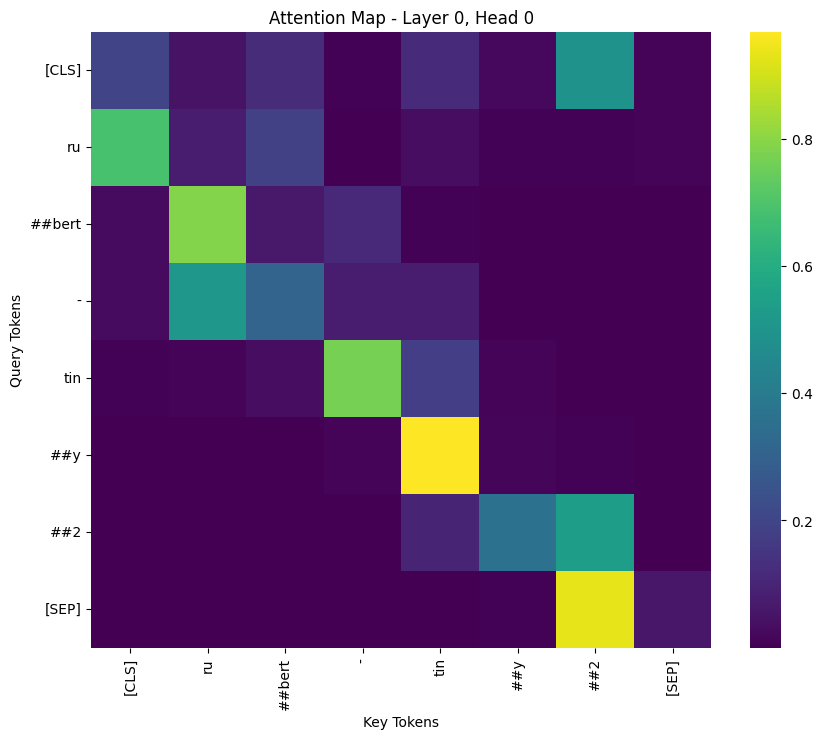

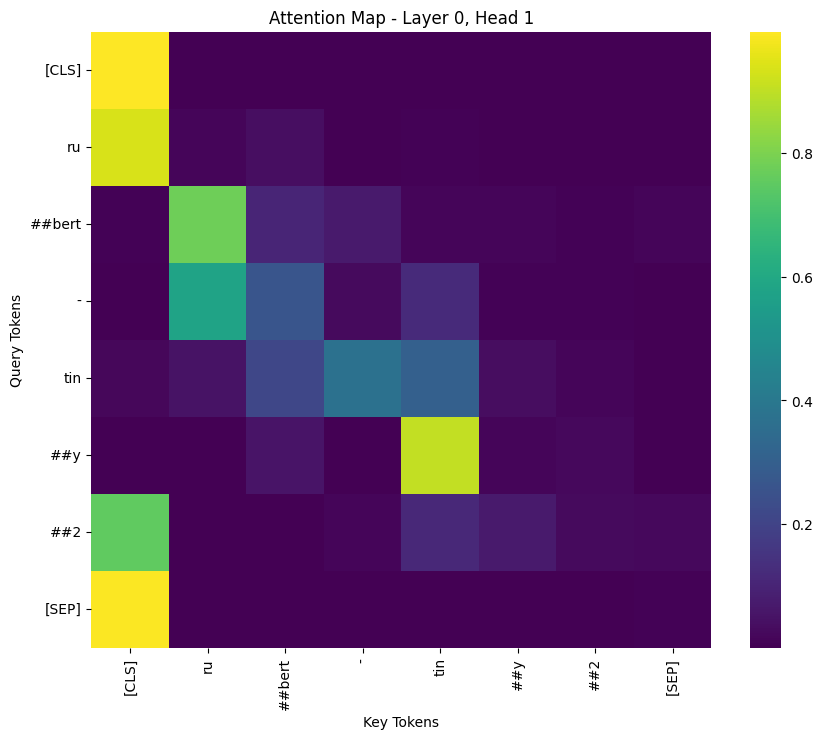

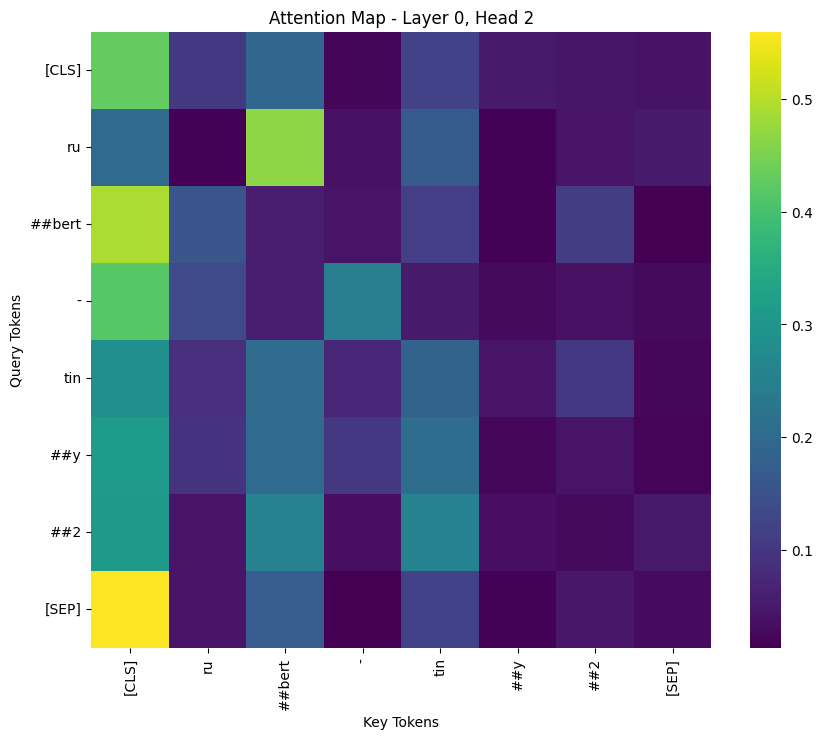

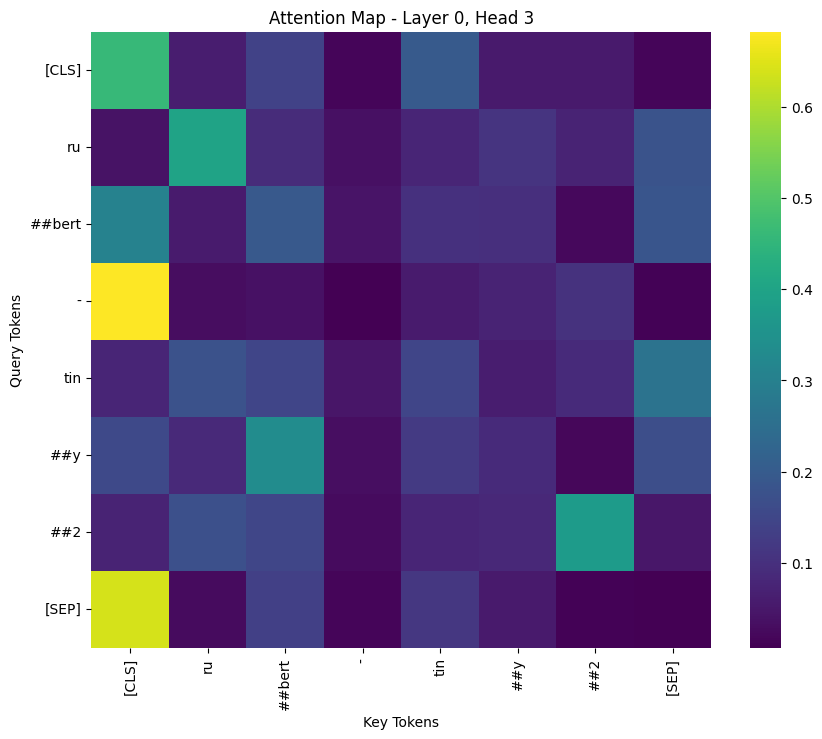

In [ ]:
text = "rubert-tiny2"
attention_head_ids = [0, 1, 2, 3]  # головы для отрисвки


# Для второй модели Rubert
draw_first_layer_attention_maps(attention_head_ids, text, rubert_tiny_transformer_model_2, "cointegrated/rubert-tiny2")


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


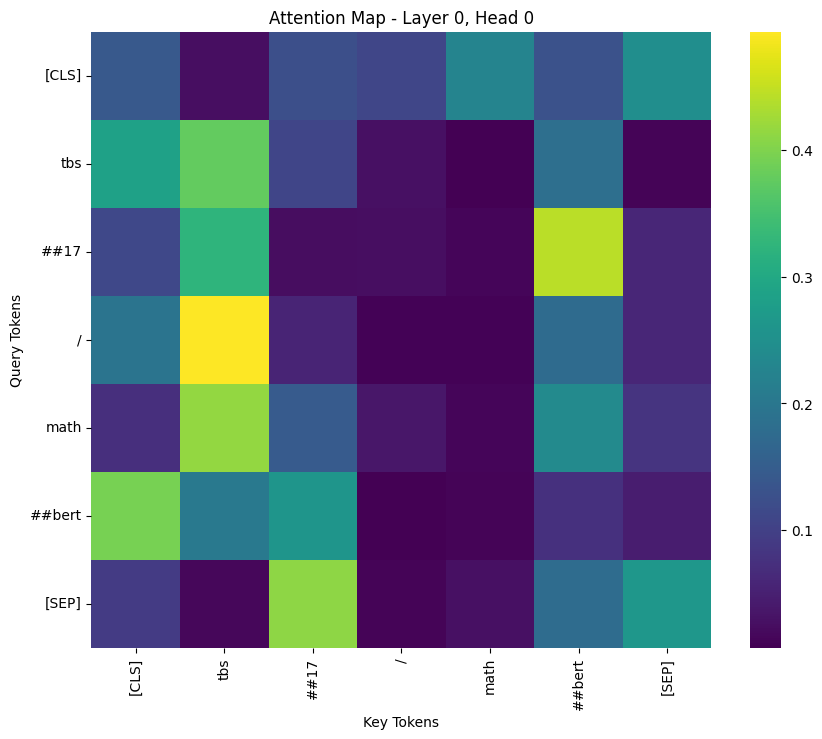

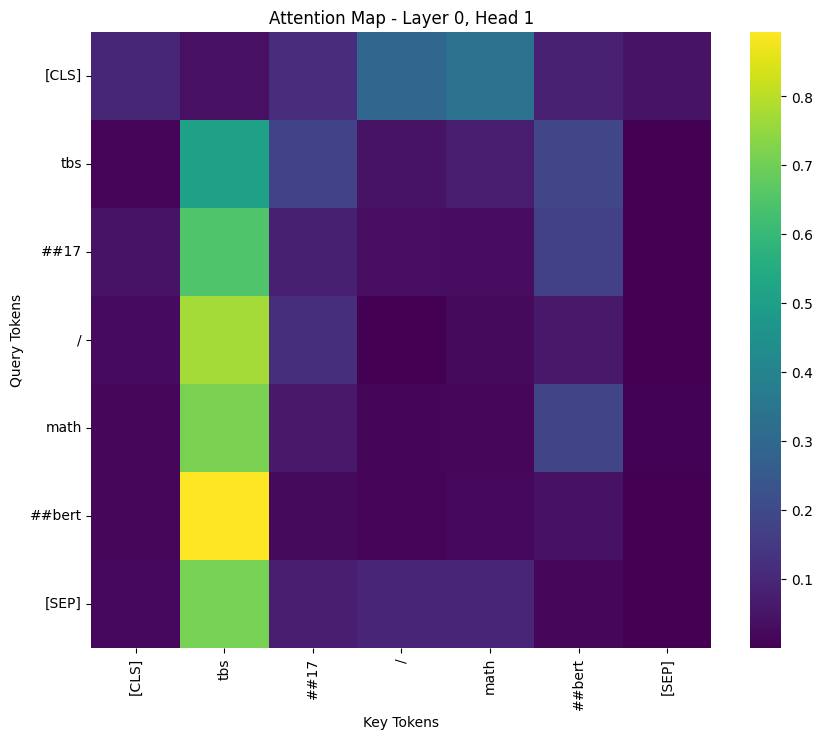

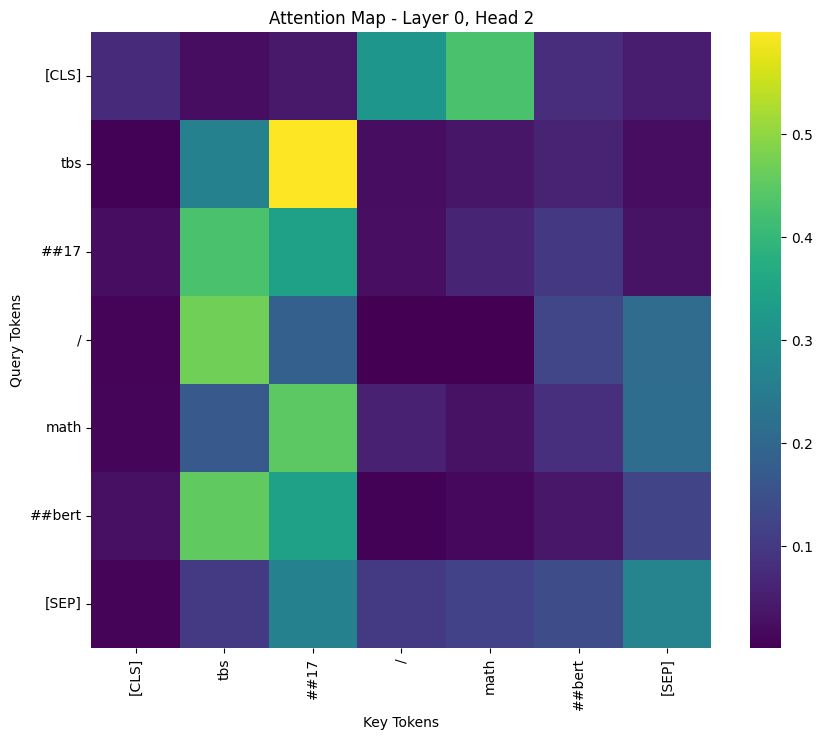

In [ ]:
text = "tbs17/MathBert"
attention_head_ids = [0, 1, 2]  # первые 3 головы

draw_first_layer_attention_maps(attention_head_ids, text, MathBert_transformer_model_2, "tbs17/MathBert")


### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [ ]:
### YOUR CODE IS HERE

In [ ]:
texts = df['problem_text'].sample(3, random_state=42).tolist()

def get_attention_first_layer(model: TransformerClassificationModel, tokenizer_name: str, text: str):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model.backbone.eval()

    encoding = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    input_ids = encoding['input_ids']
    attention_mask = encoding['attention_mask']

    with torch.no_grad():
        outputs = model.backbone(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        first_layer_attention = outputs.attentions[0][0]  # первый слой, первый батч

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    seq_len = attention_mask.sum().item()  # длина без паддинга
    tokens = tokens[:seq_len]

    first_layer_attention = first_layer_attention[:, :seq_len, :seq_len]

    return tokens, first_layer_attention

import seaborn as sns

def plot_attention_heads(tokens, attention_matrix, head_ids: list):
    for head_id in head_ids:
        if head_id >= attention_matrix.shape[0]:
            print(f"Head {head_id} не существует, всего голов: {attention_matrix.shape[0]}")
            continue
        attn = attention_matrix[head_id].cpu().numpy()
        plt.figure(figsize=(10, 8))
        sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
        plt.title(f"Attention Map - Layer 0, Head {head_id}")
        plt.xlabel("Key Tokens")
        plt.ylabel("Query Tokens")
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.show()


=== Rubert Tiny ===

Text 1: In some countries, roads are connected, each road is less than 500 km long, and from each city to any other, it is possible to travel less than 500 km on the roads. When one road is closed for repair, it has become clear that it is possible to drive less than 1,500 km from each city to any other road.



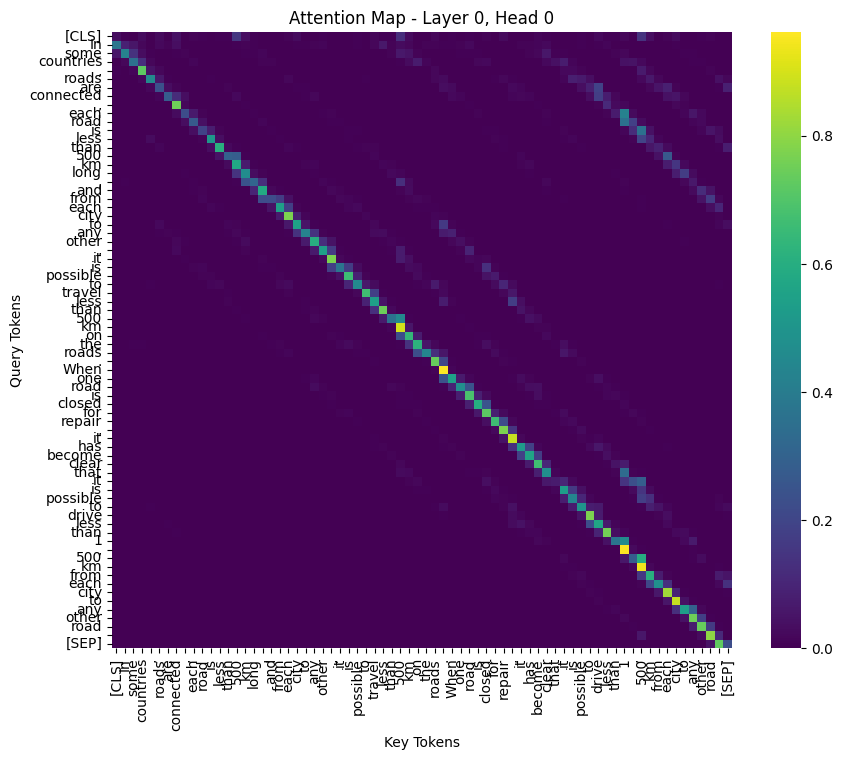

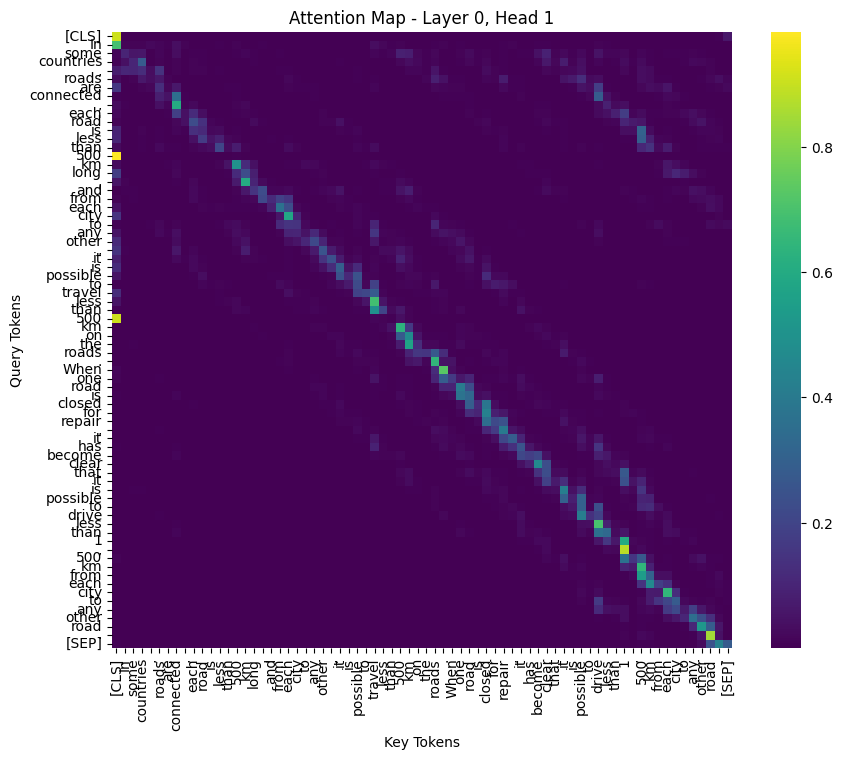

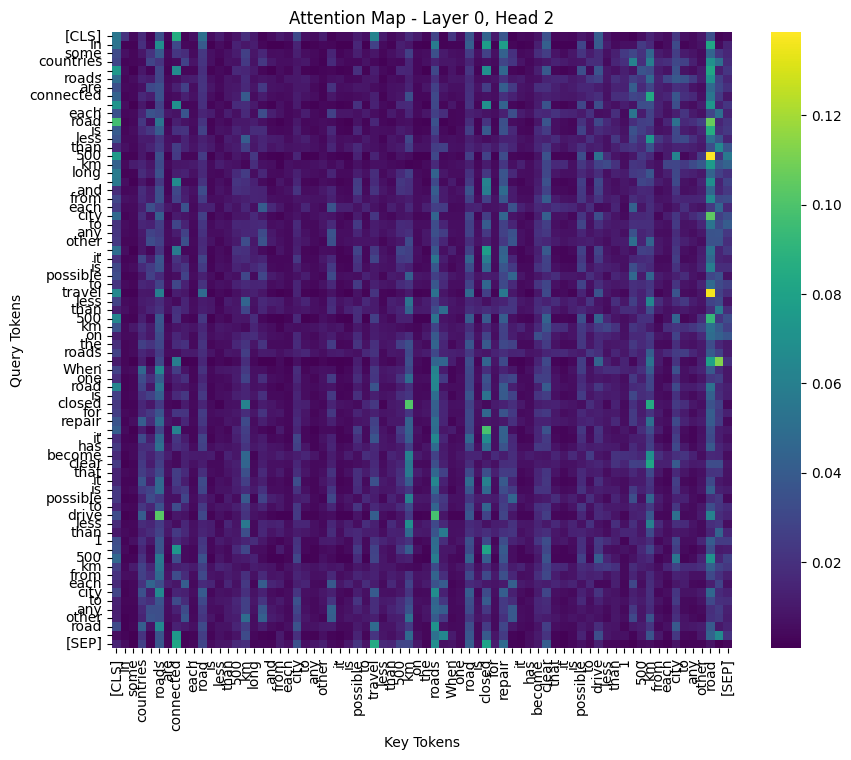

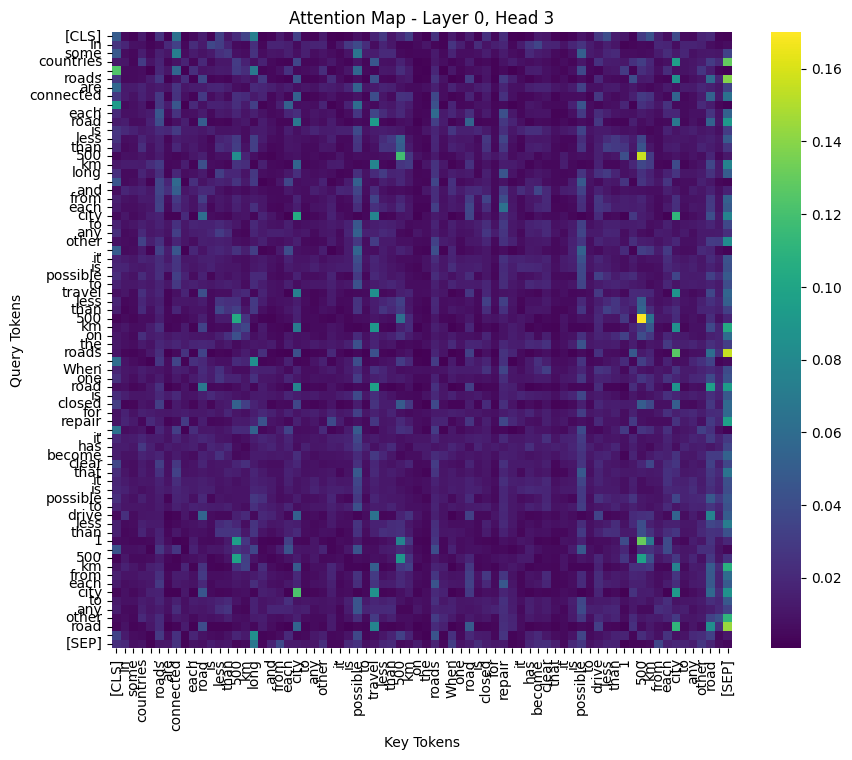


Text 2: The circle is divided by points A, B, C, D so that the AD and BC hordes continued to cross at point M. Find angle AMB.



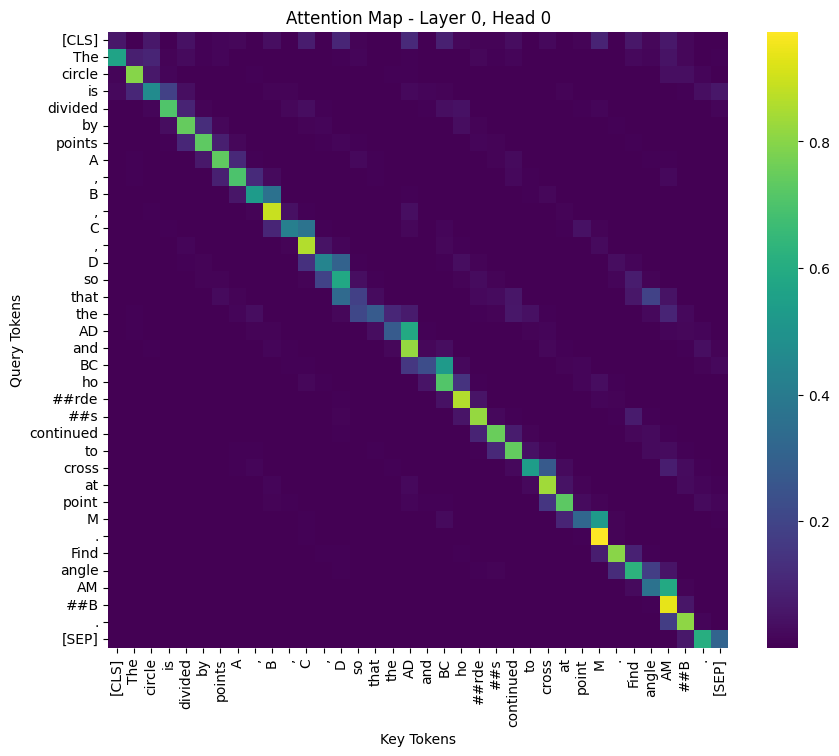

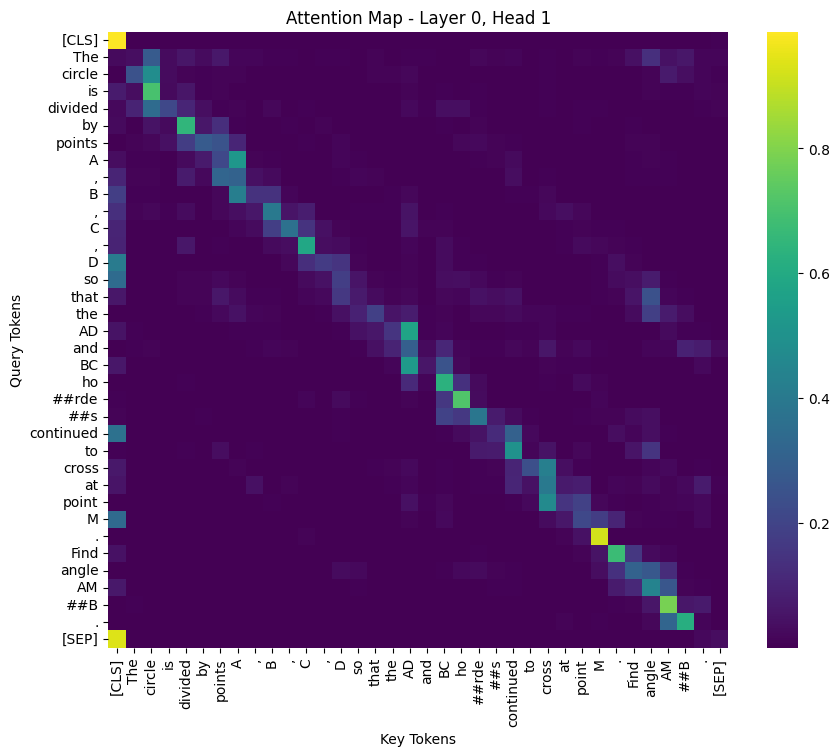

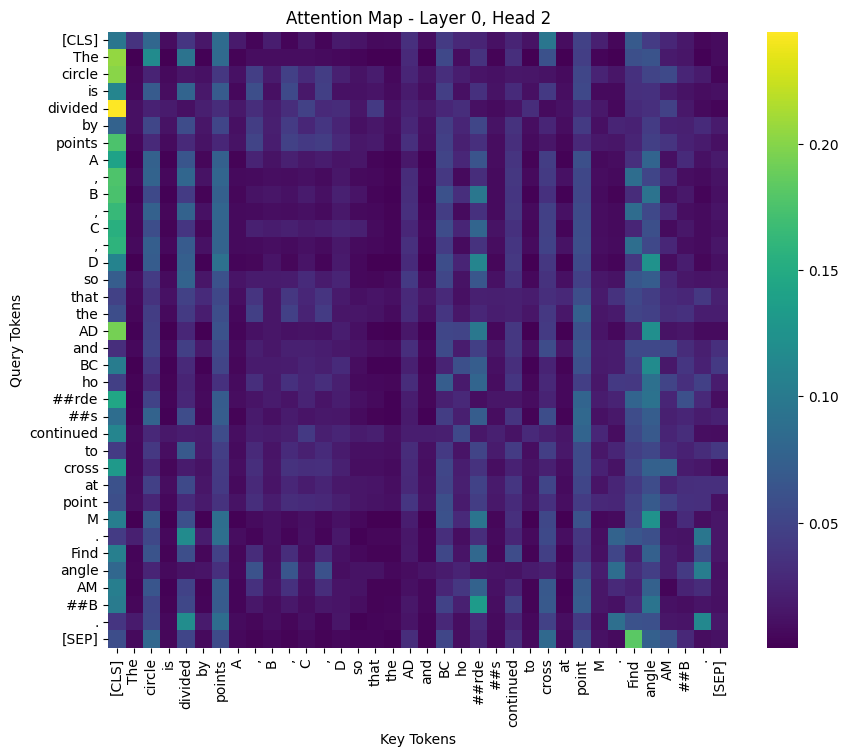

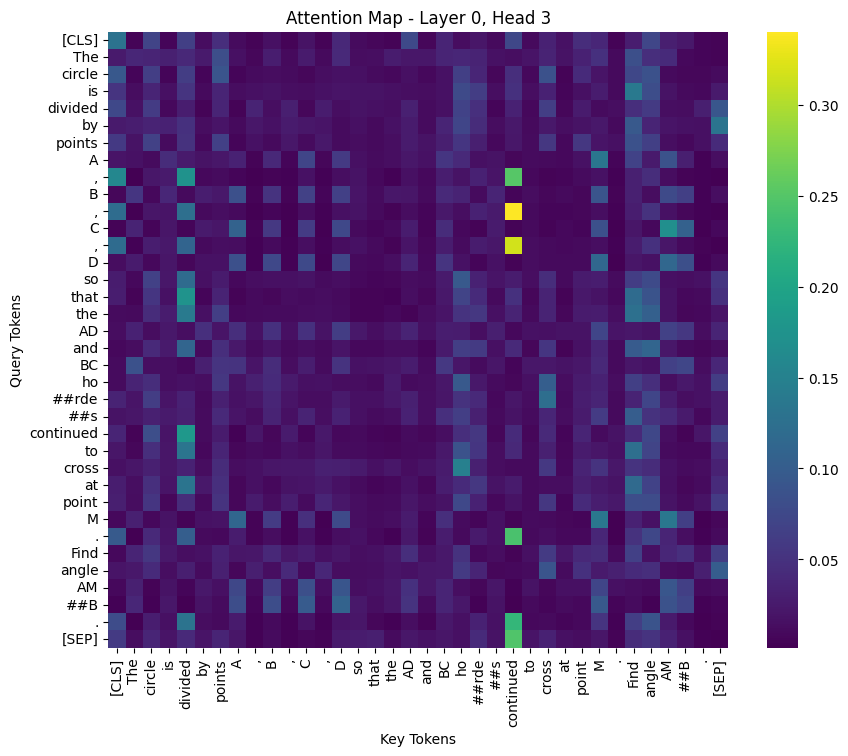


Text 3: Each of the ribs of a full graph with 17 vertices painted in one of the three colors, prove that there are three vertices, all of which are the same color.



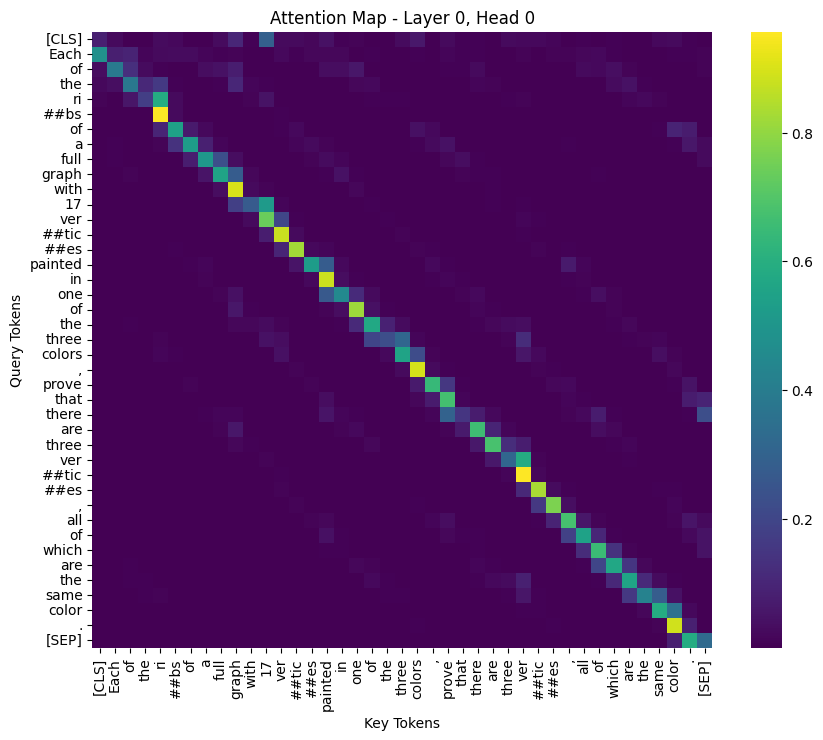

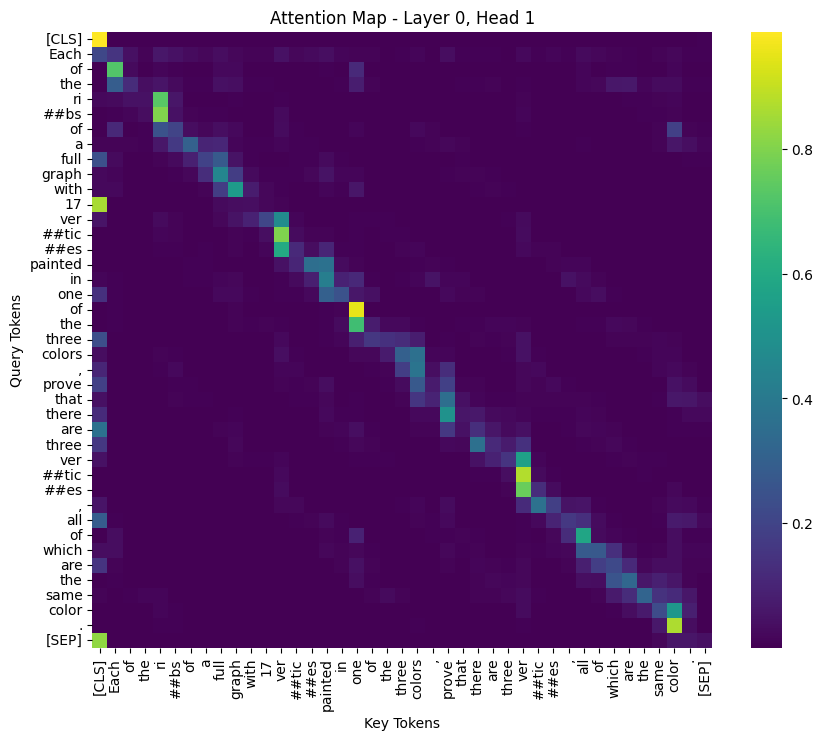

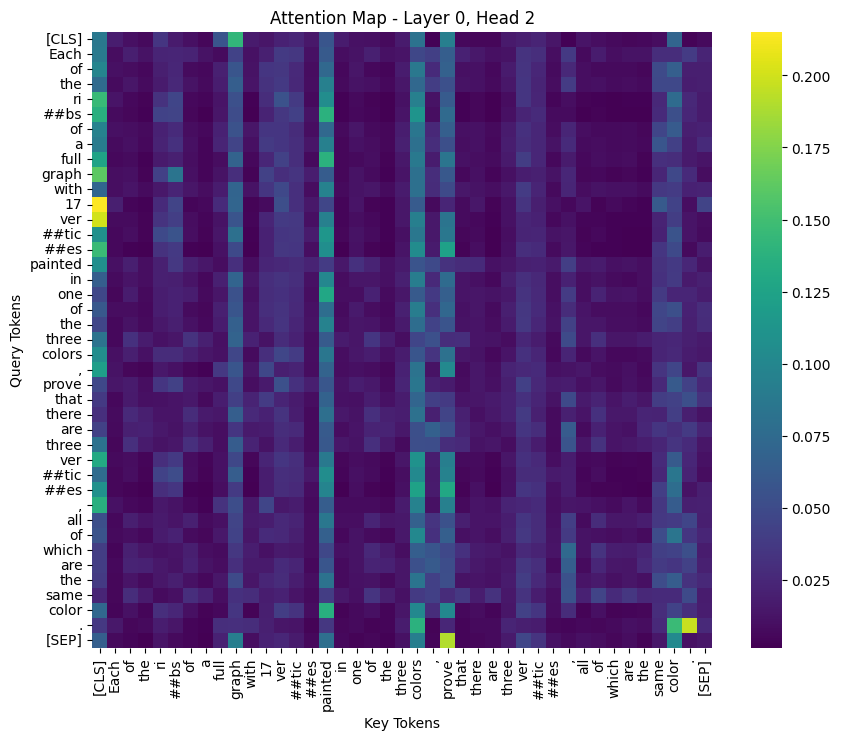

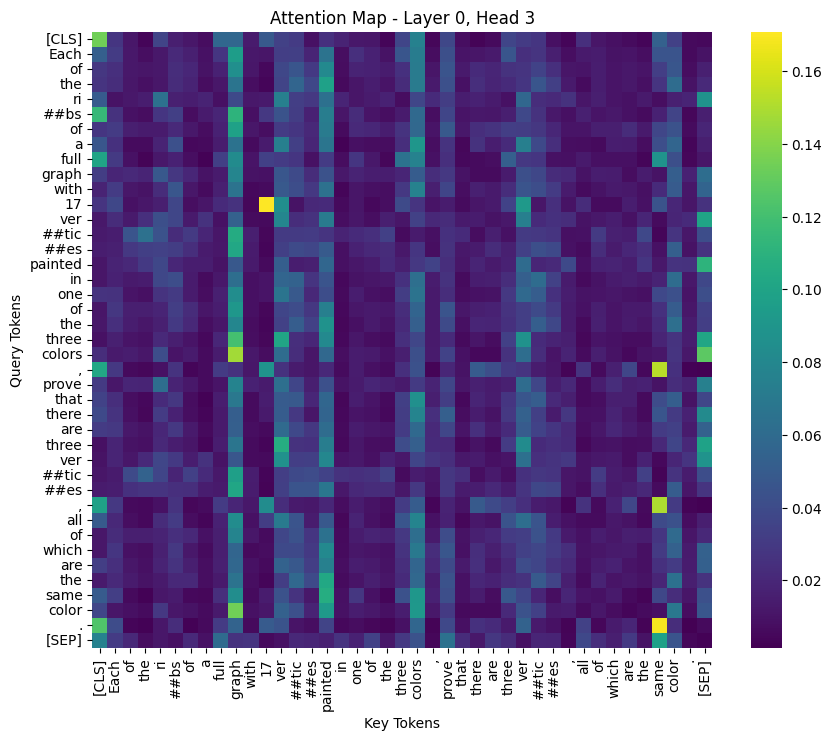


=== MathBert ===

Text 1: In some countries, roads are connected, each road is less than 500 km long, and from each city to any other, it is possible to travel less than 500 km on the roads. When one road is closed for repair, it has become clear that it is possible to drive less than 1,500 km from each city to any other road.



Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


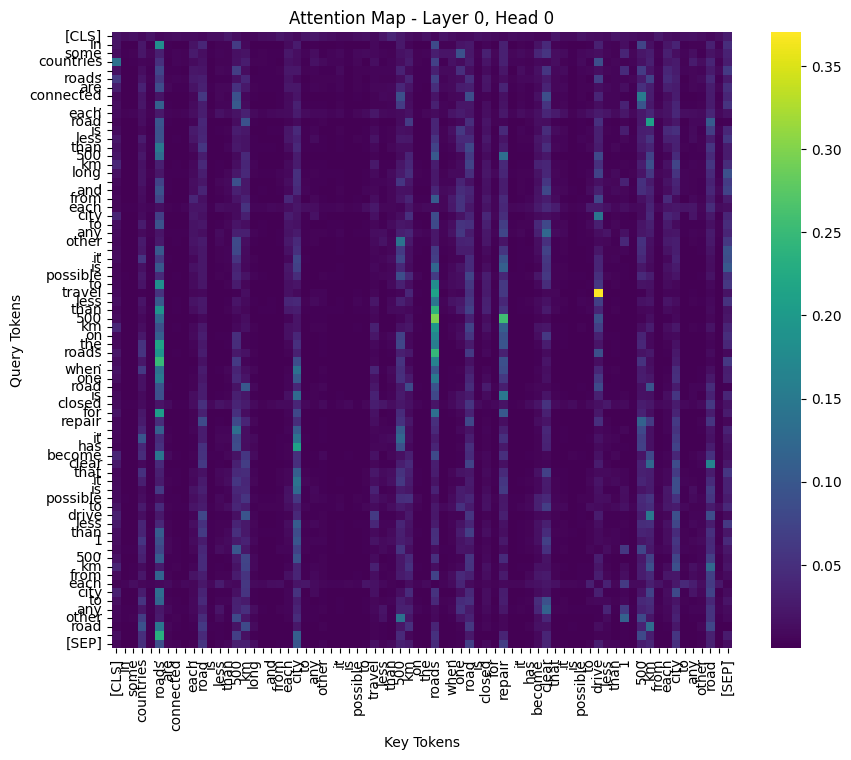

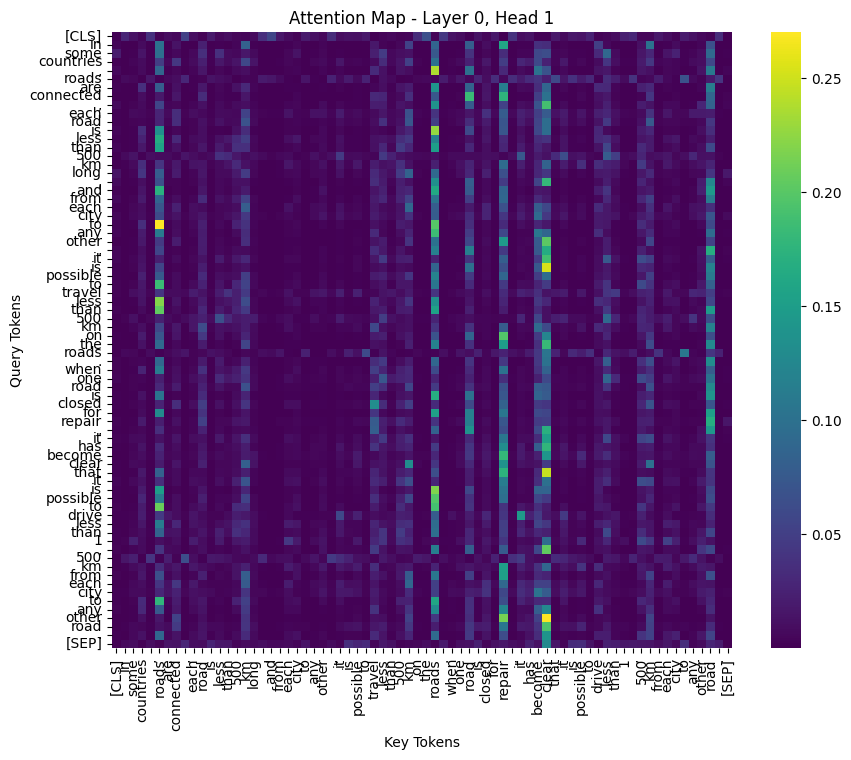

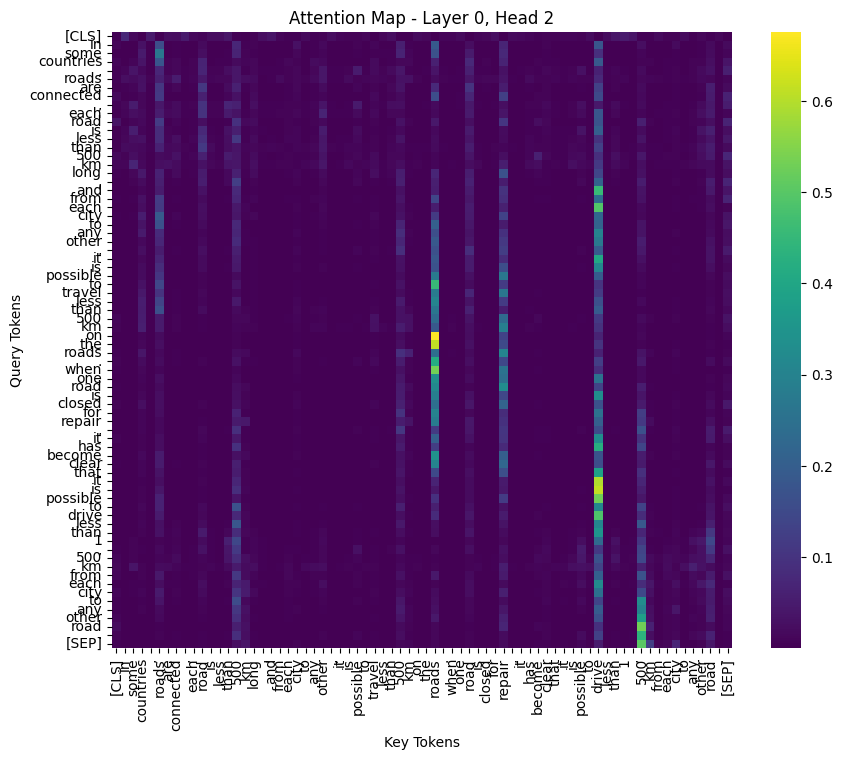

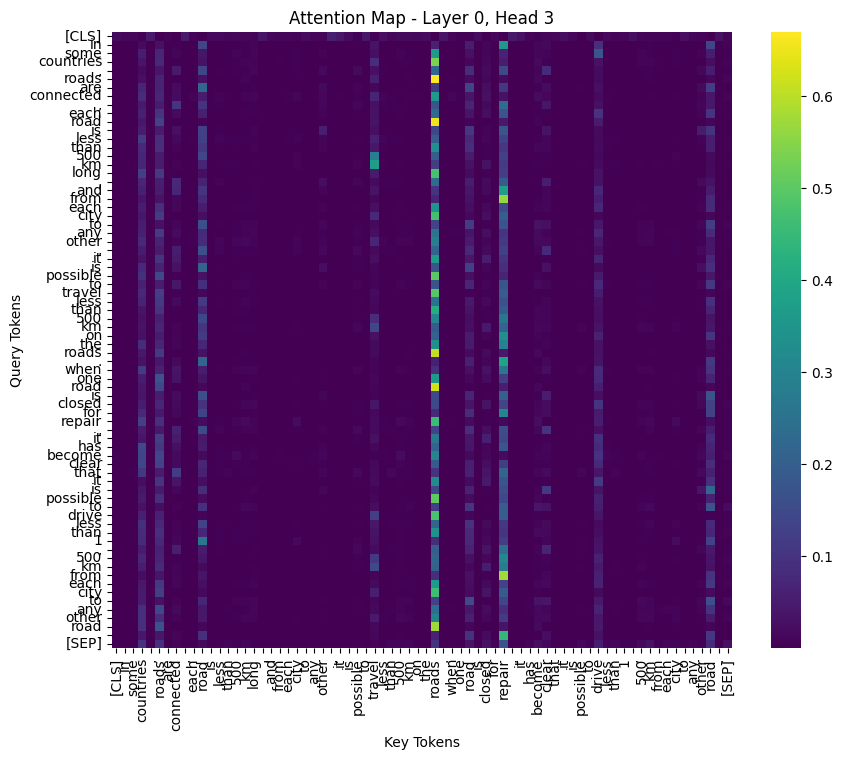


Text 2: The circle is divided by points A, B, C, D so that the AD and BC hordes continued to cross at point M. Find angle AMB.



Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


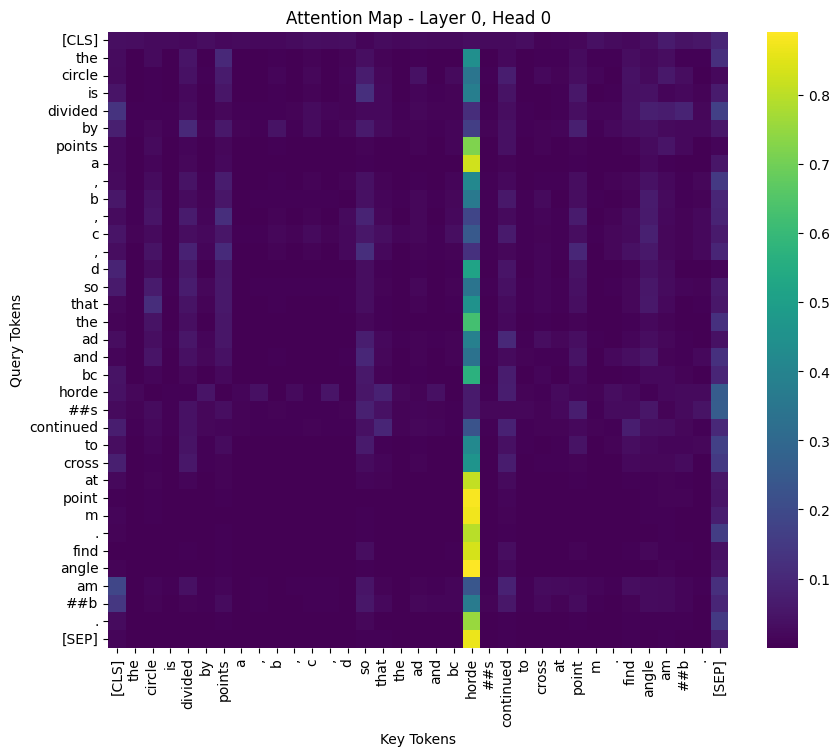

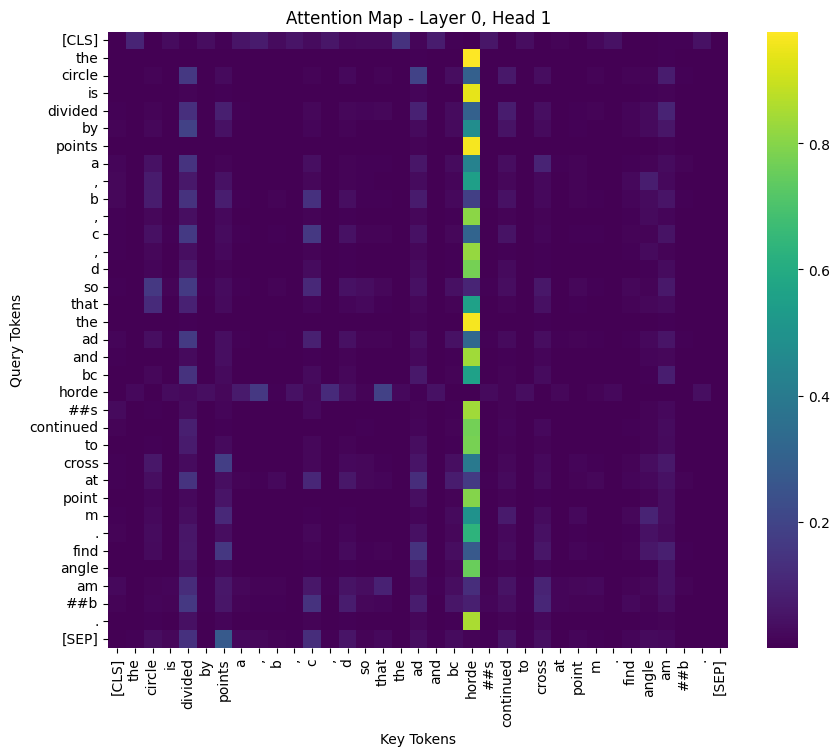

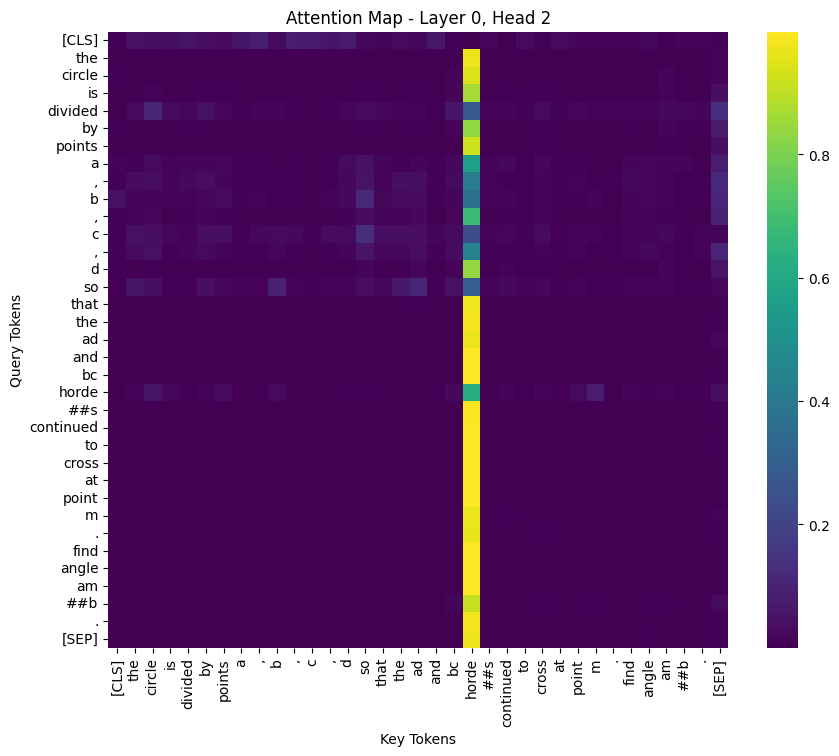

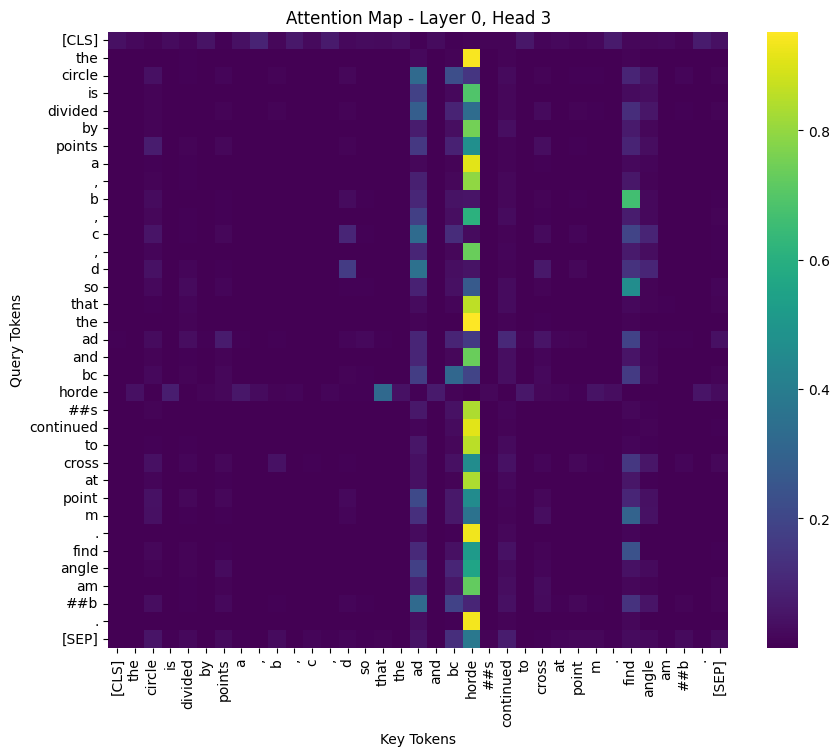


Text 3: Each of the ribs of a full graph with 17 vertices painted in one of the three colors, prove that there are three vertices, all of which are the same color.



Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


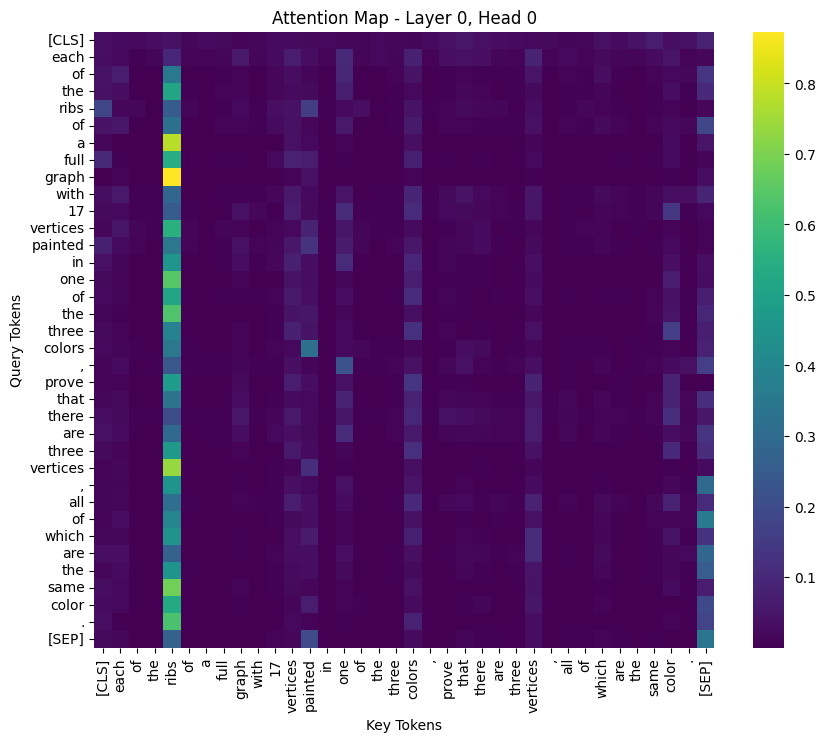

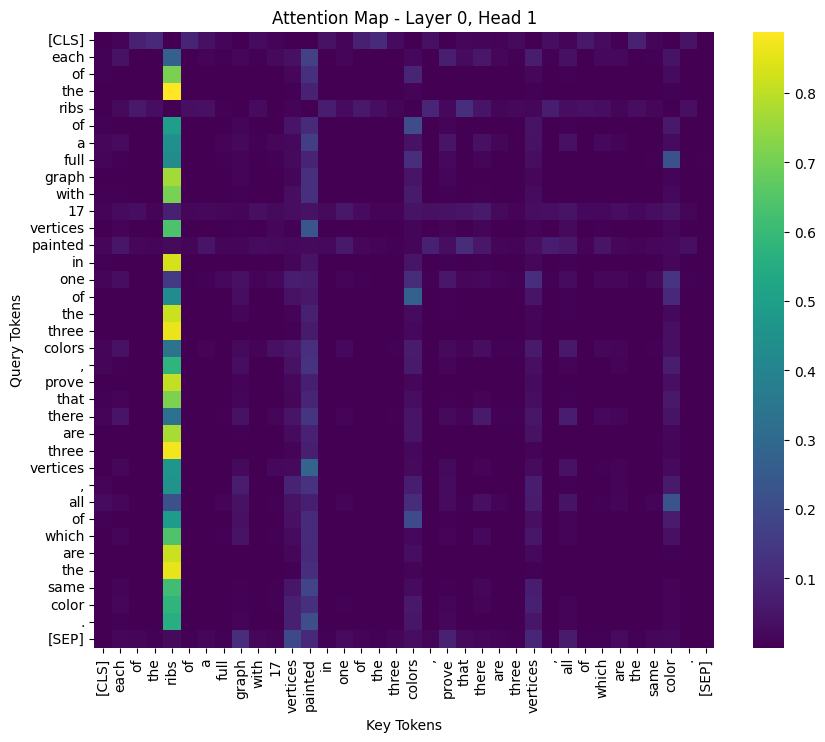

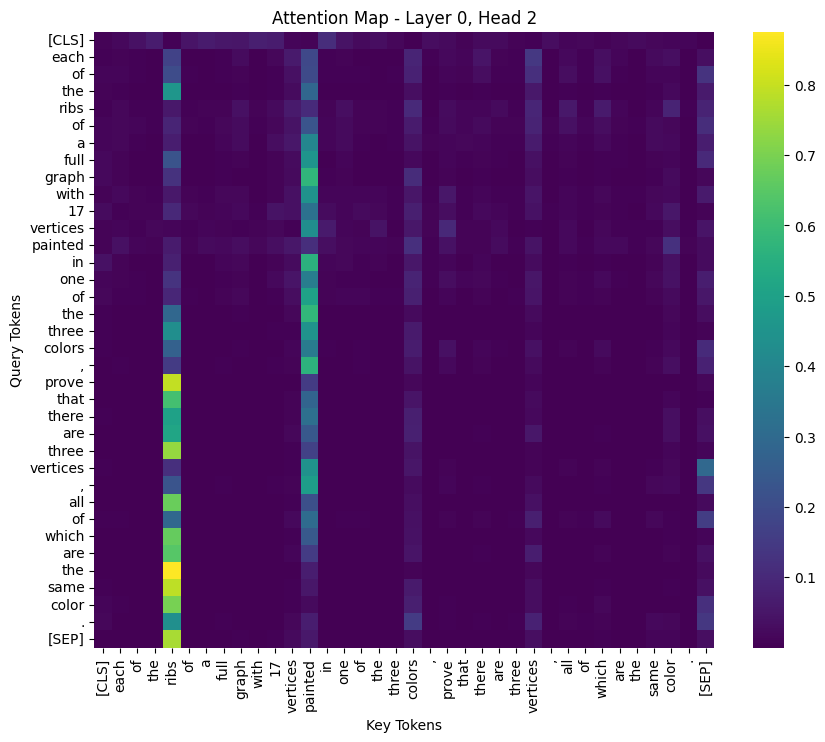

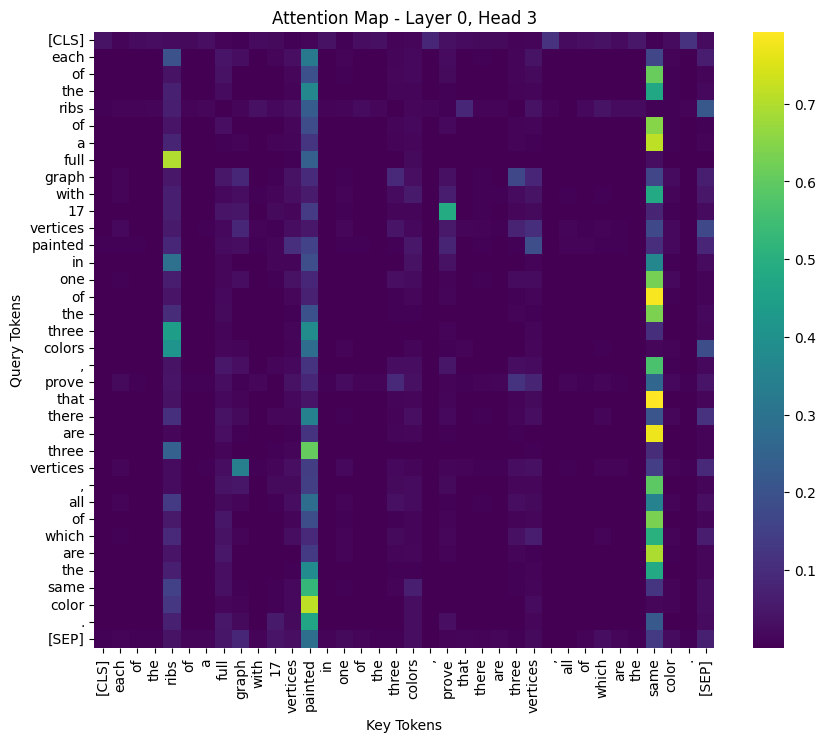

In [ ]:
models_info = [
    ("Rubert Tiny", rubert_tiny_transformer_model_1, "cointegrated/rubert-tiny2"),
    ("MathBert", MathBert_transformer_model_1, "tbs17/MathBert")
]

for model_name, model, tokenizer_name in models_info:
    print(f"\n=== {model_name} ===")
    for i, text in enumerate(texts):
        print(f"\nText {i+1}: {text}\n")
        tokens, attn_matrix = get_attention_first_layer(model, tokenizer_name, text)
        # визуализируем первые 4 головы или меньше, если голов меньше
        num_heads = attn_matrix.shape[0]
        head_ids = list(range(min(4, num_heads)))
        plot_attention_heads(tokens, attn_matrix, head_ids)

In [ ]:
# Интерпретация, как я понимаю такая - полосы показывают о "связанности" токенов между собой. ПРи этом, если вертикальные полосы говорят, что токен связан с какими-то другими, а диагональная - сам с собой(что м.б. неочень хорошо). В этом и состоит механика Внимания.

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

In [ ]:
### YOUR CODE IS HERE

In [ ]:
# # Дообученные модели
#
# # Rubert
# rubert_tiny_finetuned_with_freezed_backbone  # модель с замороженным backbone
# rubert_tiny_full_finetuned  # модель с полной дообучкой
#
# # MathBert
# MathBert_finetuned_with_freezed_backbone
# MathBert_full_finetuned

In [ ]:
# rubert_model_freeze = rubert_tiny_finetuned_with_freezed_backbone.model
# rubert_model_full = rubert_tiny_full_finetuned.model
#
# mathbert_model_freeze = MathBert_finetuned_with_freezed_backbone.model
# mathbert_model_full = MathBert_full_finetuned.model

In [ ]:
def plot_attention_heads(tokens, attn_matrix, head_ids=[0,1,2,3], title=None):
    import matplotlib.pyplot as plt
    import numpy as np

    num_heads = len(head_ids)
    fig, axes = plt.subplots(1, num_heads, figsize=(4*num_heads, 4))

    if num_heads == 1:
        axes = [axes]

    for i, head in enumerate(head_ids):
        attn = attn_matrix[head].cpu().numpy()
        axes[i].imshow(attn, cmap='viridis')
        axes[i].set_xticks(range(len(tokens)))
        axes[i].set_yticks(range(len(tokens)))
        axes[i].set_xticklabels(tokens, rotation=90, fontsize=8)
        axes[i].set_yticklabels(tokens, fontsize=8)
        axes[i].set_title(f'Head {head}')

    if title:
        plt.suptitle(title)

    plt.tight_layout()
    plt.show()


Rubert Frozen Backbone - Text 1: In some countries, roads are connected, each road is less than 500 km long, and from each city to any other, it is possible to travel less than 500 km on the roads. When one road is closed for repair, it has become clear that it is possible to drive less than 1,500 km from each city to any other road.



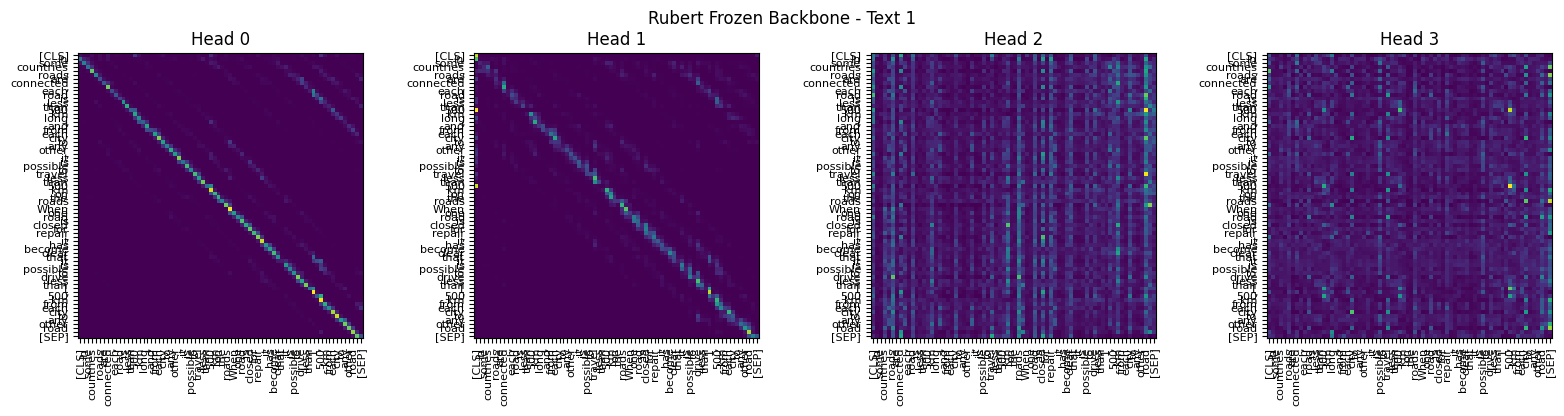


Rubert Frozen Backbone - Text 2: The circle is divided by points A, B, C, D so that the AD and BC hordes continued to cross at point M. Find angle AMB.



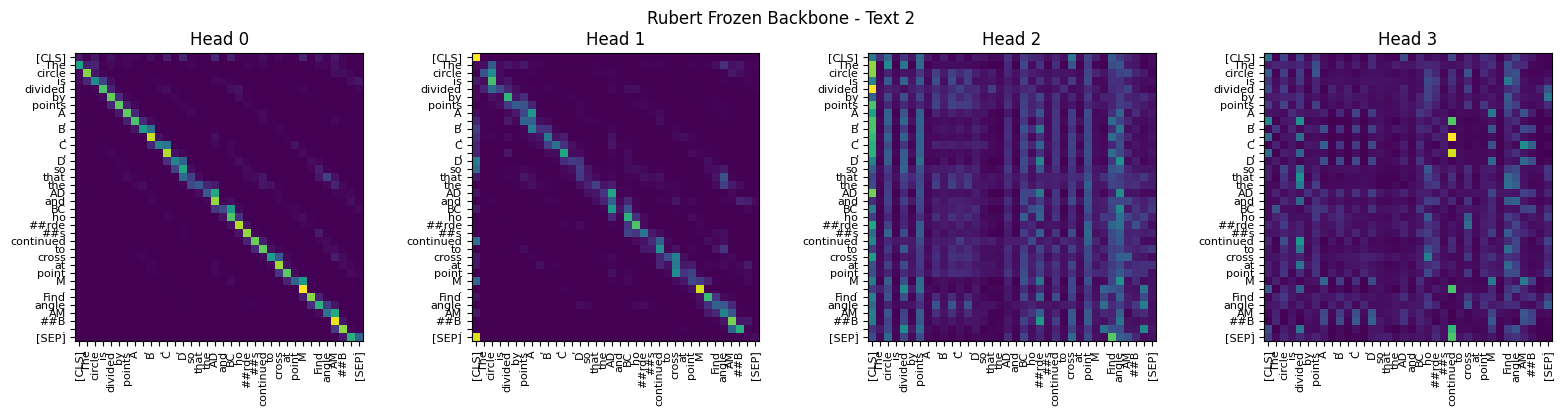


Rubert Frozen Backbone - Text 3: Each of the ribs of a full graph with 17 vertices painted in one of the three colors, prove that there are three vertices, all of which are the same color.



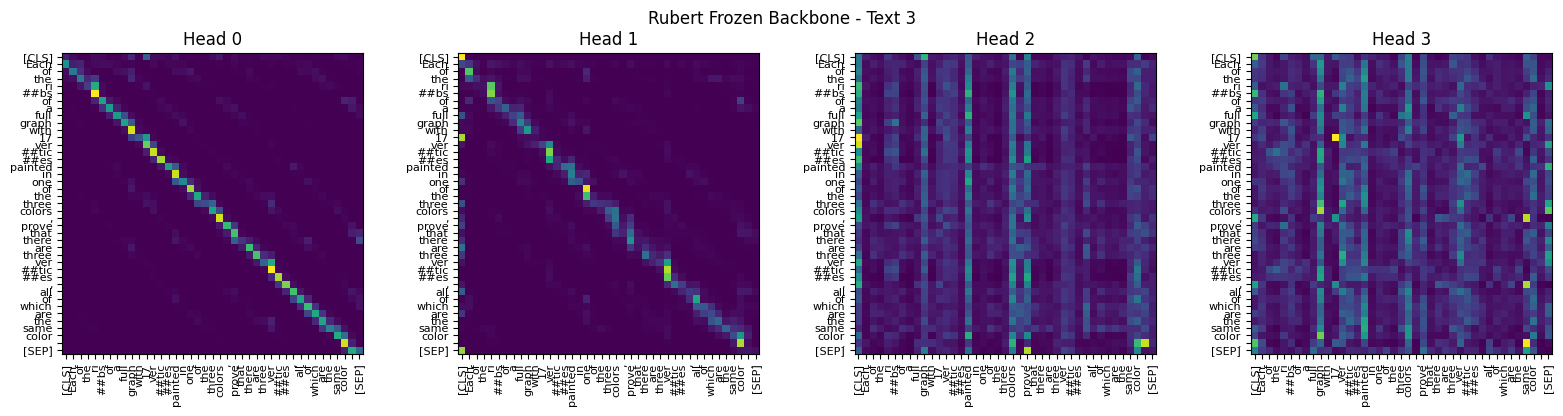


Rubert Full Fine-Tune - Text 1: In some countries, roads are connected, each road is less than 500 km long, and from each city to any other, it is possible to travel less than 500 km on the roads. When one road is closed for repair, it has become clear that it is possible to drive less than 1,500 km from each city to any other road.



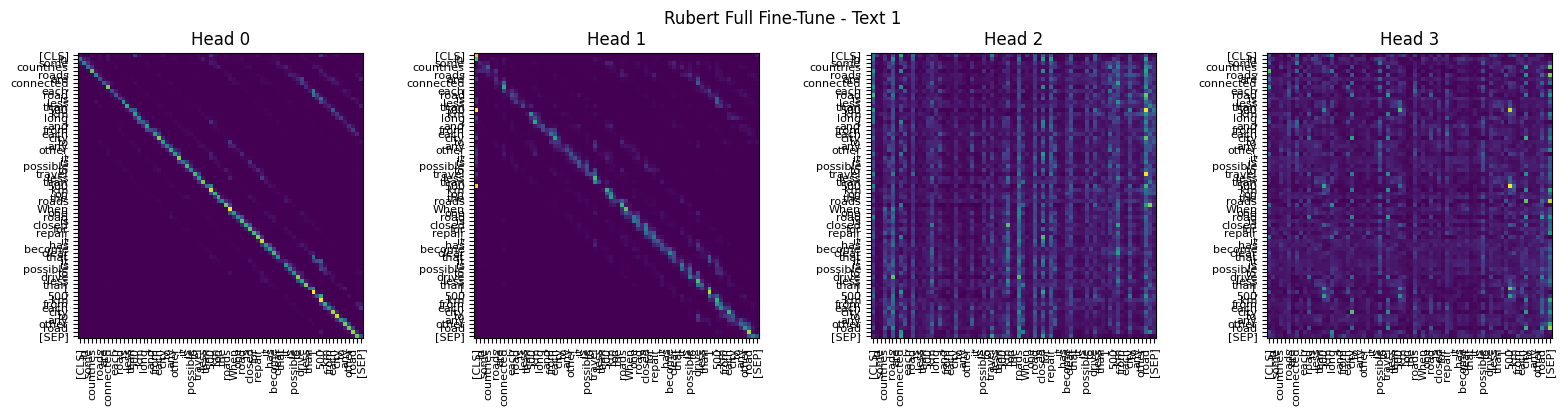


Rubert Full Fine-Tune - Text 2: The circle is divided by points A, B, C, D so that the AD and BC hordes continued to cross at point M. Find angle AMB.



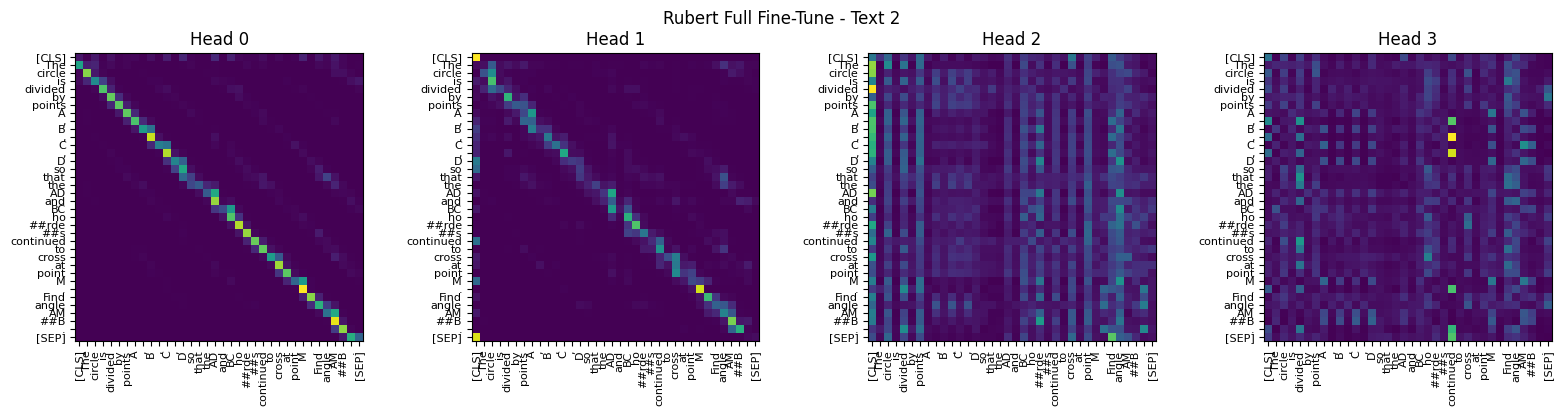


Rubert Full Fine-Tune - Text 3: Each of the ribs of a full graph with 17 vertices painted in one of the three colors, prove that there are three vertices, all of which are the same color.



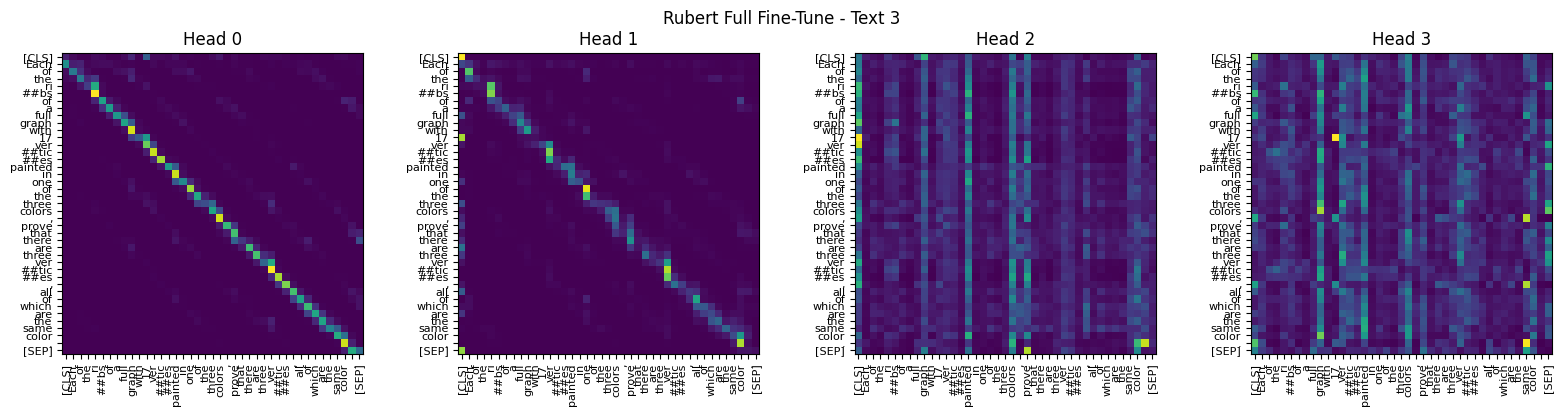


MathBert Frozen Backbone - Text 1: In some countries, roads are connected, each road is less than 500 km long, and from each city to any other, it is possible to travel less than 500 km on the roads. When one road is closed for repair, it has become clear that it is possible to drive less than 1,500 km from each city to any other road.



Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


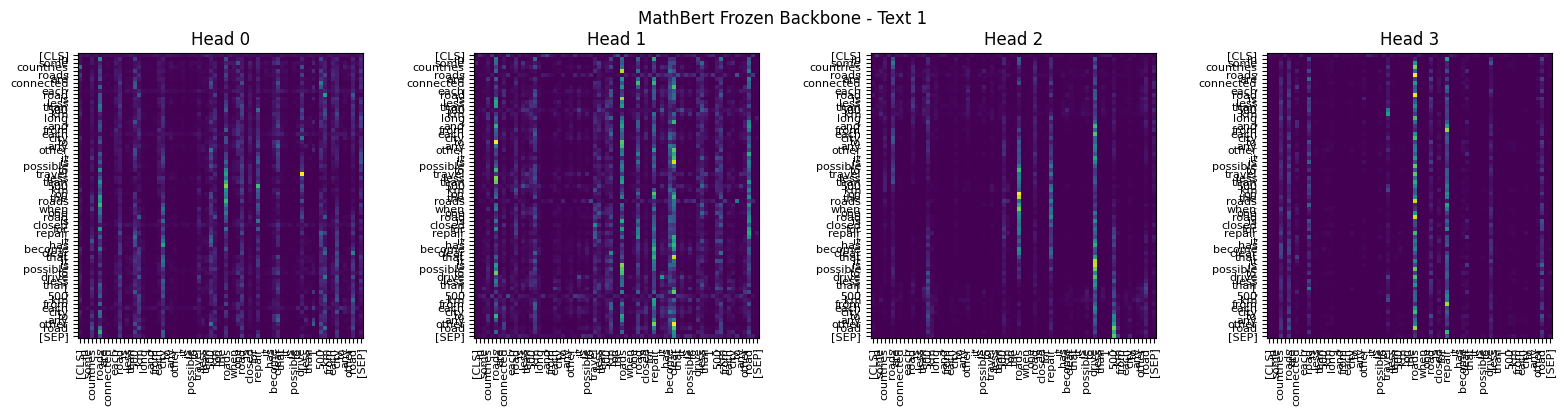


MathBert Frozen Backbone - Text 2: The circle is divided by points A, B, C, D so that the AD and BC hordes continued to cross at point M. Find angle AMB.



Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


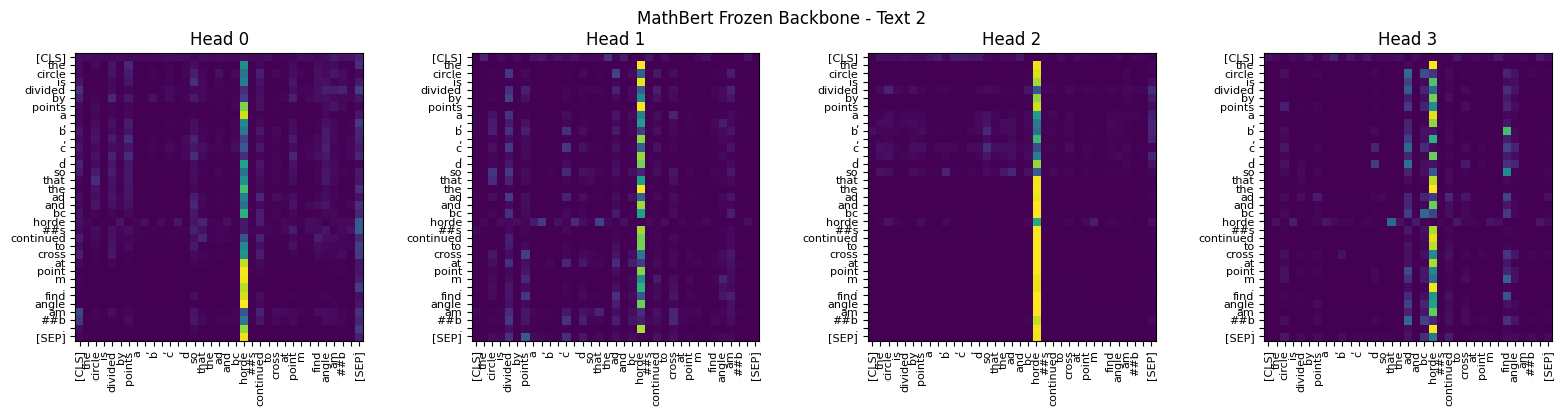


MathBert Frozen Backbone - Text 3: Each of the ribs of a full graph with 17 vertices painted in one of the three colors, prove that there are three vertices, all of which are the same color.



Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


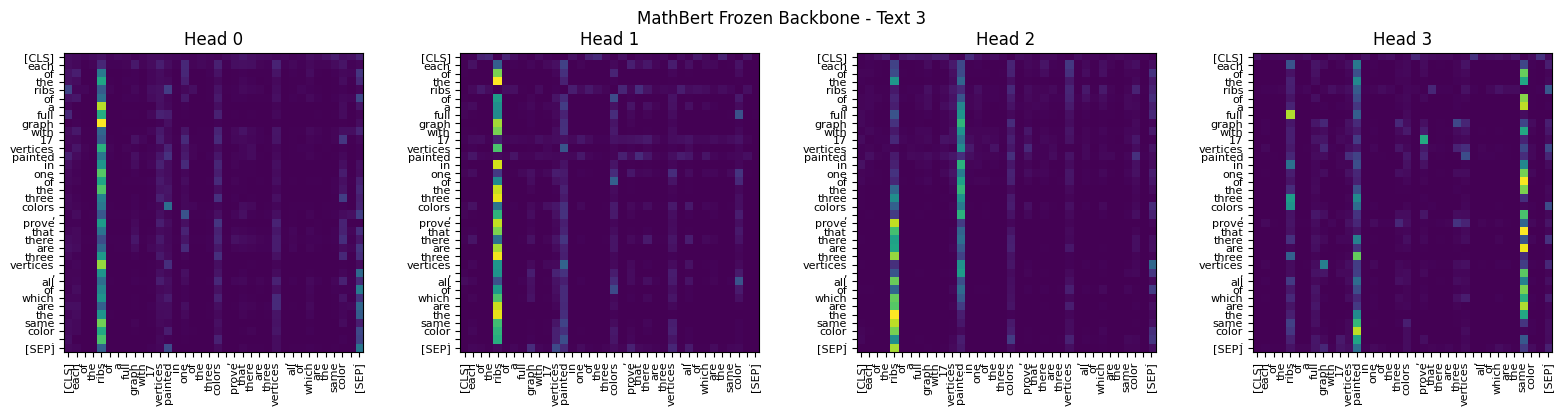


MathBert Full Fine-Tune - Text 1: In some countries, roads are connected, each road is less than 500 km long, and from each city to any other, it is possible to travel less than 500 km on the roads. When one road is closed for repair, it has become clear that it is possible to drive less than 1,500 km from each city to any other road.



Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


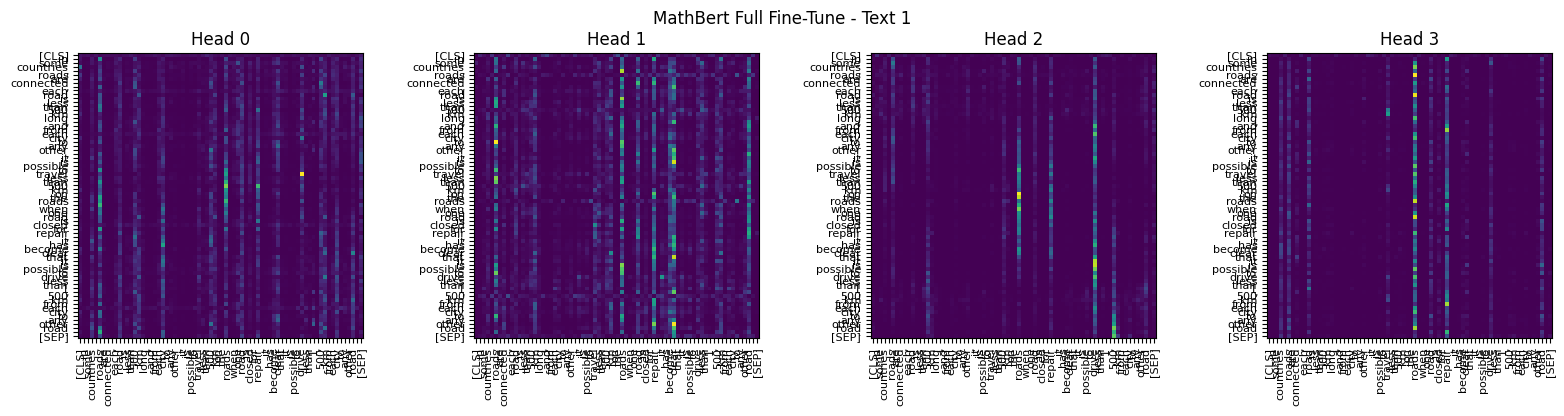


MathBert Full Fine-Tune - Text 2: The circle is divided by points A, B, C, D so that the AD and BC hordes continued to cross at point M. Find angle AMB.



Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


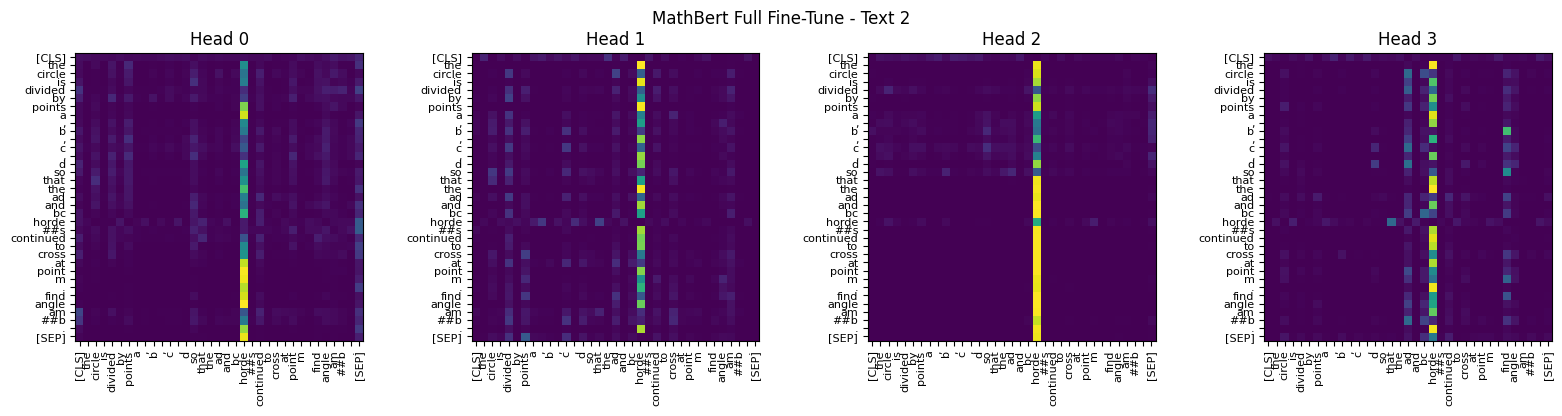


MathBert Full Fine-Tune - Text 3: Each of the ribs of a full graph with 17 vertices painted in one of the three colors, prove that there are three vertices, all of which are the same color.



Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


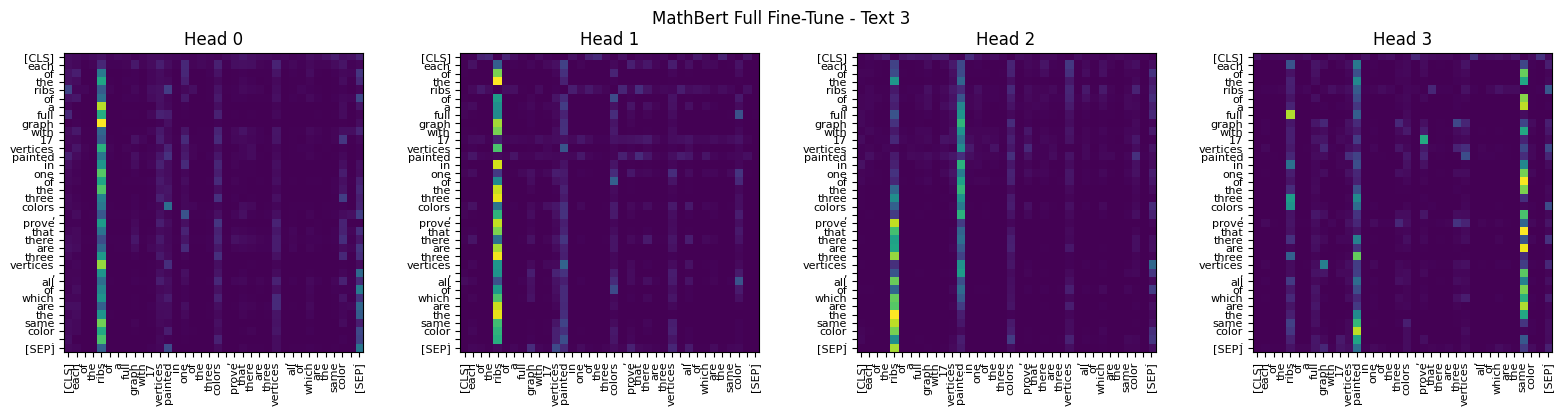

In [ ]:
texts = df['problem_text'].sample(3, random_state=42).tolist()

for i, text in enumerate(texts):
    print(f"\nRubert Frozen Backbone - Text {i+1}: {text}\n")
    tokens, attn_matrix = get_attention_first_layer(rubert_tiny_transformer_model_1, "cointegrated/rubert-tiny2", text)
    plot_attention_heads(tokens, attn_matrix, head_ids=[0,1,2,3], title=f"Rubert Frozen Backbone - Text {i+1}")


for i, text in enumerate(texts):
    print(f"\nRubert Full Fine-Tune - Text {i+1}: {text}\n")
    tokens, attn_matrix = get_attention_first_layer(rubert_tiny_transformer_model_2, "cointegrated/rubert-tiny2", text)
    plot_attention_heads(tokens, attn_matrix, head_ids=[0,1,2,3], title=f"Rubert Full Fine-Tune - Text {i+1}")


for i, text in enumerate(texts):
    print(f"\nMathBert Frozen Backbone - Text {i+1}: {text}\n")
    tokens, attn_matrix = get_attention_first_layer(MathBert_transformer_model_1, "tbs17/MathBert", text)
    plot_attention_heads(tokens, attn_matrix, head_ids=[0,1,2,3], title=f"MathBert Frozen Backbone - Text {i+1}")

for i, text in enumerate(texts):
    print(f"\nMathBert Full Fine-Tune - Text {i+1}: {text}\n")
    tokens, attn_matrix = get_attention_first_layer(MathBert_transformer_model_2, "tbs17/MathBert", text)
    plot_attention_heads(tokens, attn_matrix, head_ids=[0,1,2,3], title=f"MathBert Full Fine-Tune - Text {i+1}")



In [ ]:
# Карты внимания для дообученных моделей стали как буд-то немного "скоординированными" - как мне кажется в следствии собственно обучения и "усиления внимания" по определенным
# признакам(меньше "размазанность признаков", т.е. достигается хорошая семантическая связь токеном). Отсутствие диагональных полос говорит об отсутствии "замыкания" токенов на самих себя.
# Тем не менее, нужно больше экспериментов.